In [68]:
# --- 1. Imports, Configuration & Paths ---
import os
import re
import yaml
import shutil
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.colors import ListedColormap
import random
import multiprocessing
from concurrent.futures import ThreadPoolExecutor

# --- IEEE / Paper Plotting Style ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.dpi'] = 300 

# --- Paths ---
NOXIM_BIN_DIR = Path("../bin").resolve()
NOXIM_EXEC = "./noxim"
CONFIG_DIR = Path("../custom_config").resolve()
TEMP_CONFIG_DIR = Path("temp_configs").resolve()
TEMP_CONFIG_DIR.mkdir(exist_ok=True)
PLOTS_DIR = Path("plots").resolve()
PLOTS_DIR.mkdir(exist_ok=True)

# --- Parallelization ---
# Use (CPU Cores - 1) to keep the system responsive, or specific number
MAX_WORKERS = max(1, multiprocessing.cpu_count() - 1)
print(f"Parallel execution enabled with {MAX_WORKERS} workers.")

NUM_SEEDS = 10  # Set to 1 as requested, can increase for more statistical robustness
SEEDS = [random.randint(1, 10000) for _ in range(NUM_SEEDS)]

# --- Protocols & Configs ---
PROTOCOLS = {
    "Token Passing": CONFIG_DIR / "token_packet_soteriou_traffic.yaml",
    "Fuzzy Token": CONFIG_DIR / "fuzzy_token_soteriou_traffic.yaml",
    "FP-Jump": CONFIG_DIR / "fuzzy_swj_soteriou_traffic.yaml",
    # "FP-Jump + RG": CONFIG_DIR / "fuzzy_raj_soteriou_traffic.yaml"
}

# --- Parsing Patterns ---
METRIC_PATTERNS = {
    "network_throughput": re.compile(r"Network throughput \(flits/cycle\):\s*([0-9.]+)"),
    "global_average_delay": re.compile(r"Global average delay \(cycles\):\s*([0-9.]+)"),
    "total_energy": re.compile(r"Total energy \(J\):\s*([0-9.eE+-]+)"),
    "dynamic_energy": re.compile(r"Dynamic energy \(J\):\s*([0-9.eE+-]+)"),
    "static_energy": re.compile(r"Static energy \(J\):\s*([0-9.eE+-]+)"),
    "received_packets": re.compile(r"Total received packets:\s*([0-9]+)"),
    "received_flits": re.compile(r"Total received flits:\s*([0-9]+)"),
    "p95_delay": re.compile(r"95th Percentile Latency \(cycles\):\s*([0-9.]+)"),
    "p99_delay": re.compile(r"99th Percentile Latency \(cycles\):\s*([0-9.]+)"),
}

Parallel execution enabled with 7 workers.


In [69]:
# --- 2. Helper Functions (Simulation & Plotting) ---

def parse_noxim_output(output):
    """Parses stdout from noxim to extract defined metrics."""
    metrics = {}
    for key, pattern in METRIC_PATTERNS.items():
        match = pattern.search(output)
        if match:
            metrics[key] = float(match.group(1))
        else:
            metrics[key] = float("nan")
    return metrics

def run_noxim(config_path, pir_val=None, seed=42, overrides=None):
    """
    Runs noxim with the given config and arguments.
    """
    cmd = [NOXIM_EXEC, "-config", str(config_path), "-seed", str(seed)]
    
    if pir_val is not None:
        cmd.extend(["-pir", str(pir_val), "poisson"])
    
    if overrides:
        for k, v in overrides.items():
            cmd.append(k)
            if isinstance(v, list):
                cmd.extend([str(i) for i in v])
            else:
                cmd.append(str(v))
                
    try:
        proc = subprocess.run(
            cmd, 
            cwd=str(NOXIM_BIN_DIR), 
            capture_output=True, 
            text=True, 
            timeout=120
        )
        if proc.returncode != 0:
            print(f"Error running noxim: {proc.stderr}")
            return {}
        return parse_noxim_output(proc.stdout)
    except Exception as e:
        print(f"Exception: {e}")
        return {}

def run_with_temp_config(base_cfg, unique_filename, seed, pir_val):
    """
    Helper to create a temp config, run noxim, and cleanup.
    Useful for parallel execution where each task needs a unique config file.
    """
    temp_path = TEMP_CONFIG_DIR / unique_filename
    with open(temp_path, 'w') as f:
        yaml.dump(base_cfg, f)
        
    try:
        return run_noxim(temp_path, pir_val=pir_val, seed=seed)
    finally:
        if temp_path.exists():
            try:
                temp_path.unlink()
            except:
                pass

def calculate_gmean(values):
    """Calculates Geometric Mean, handling non-positive values safely."""
    if not values: return float("nan")
    a = np.array(values)
    a = a[a > 0] # Filter non-positive for log
    if len(a) == 0: return 0.0
    return np.exp(np.mean(np.log(a)))

def aggregate_runs(run_list):
    """
    Aggregates a list of metric dictionaries using Geometric Mean for all numerical fields.
    """
    if not run_list: return {}
    
    agg = {}
    keys = run_list[0].keys()
    
    for k in keys:
        values = [r.get(k, float('nan')) for r in run_list]
        agg[k] = calculate_gmean(values)
        
    return agg

def plot_comparisons(df, x_col, y_col, title, ylabel, log_y=False, filename=None, legend=True):
    """
    Generic plotting function for protocol comparisons.
    """
    plt.figure(figsize=(8, 6))
    
    style_map = {
        "Token Passing":      {"marker": "x", "color": "#333333", "linestyle": "--", "label": "Token Passing (Baseline)"},
        "Fuzzy Token":        {"marker": "o", "color": "#1f77b4", "linestyle": "-",  "label": "Fuzzy Token"},
        "FP-Jump":            {"marker": "D", "color": "#2ca02c", "linestyle": "-",  "label": "FP-Jump (Proposed)"},
        "FP-Jump + RG":       {"marker": "^", "color": "#e2de10", "linestyle": "-.", "label": "FP-Jump + RG (Ideal)"}
    }

    for proto in df["protocol"].unique():
        if proto not in style_map: continue
        subset = df[df["protocol"] == proto].sort_values(x_col)
        
        s = style_map[proto]
        plt.plot(subset[x_col], subset[y_col], 
                 label=s["label"], 
                 marker=s["marker"], 
                 color=s["color"], 
                 linestyle=s["linestyle"],
                 linewidth=2 if proto == "FP-Jump" else 1.5, 
                 markersize=8 if proto == "FP-Jump" else 7,
                 markeredgewidth=1.5,
                 alpha=0.9)
    
    if (x_col == "pir"):
        plt.xlabel("Packet Injection Rate (packets/cycle/node)")
    elif (x_col == "hurst"):
        plt.xlabel("Hurst Exponent (H)")
    else:
        plt.xlabel(x_col.replace("_", " ").title())
        
    plt.ylabel(ylabel)
    # plt.title(title, pad=15)
    
    if log_y: 
        plt.yscale("log")
        
    plt.grid(True, which="both", linestyle=':', linewidth=0.5, alpha=0.6, color='gray')
    if legend:
        plt.legend(frameon=True, fancybox=False, edgecolor='black', loc='best')
    plt.tight_layout()
    
    if filename:
        save_path = PLOTS_DIR / filename
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

In [70]:
# --- 3. Simulation: PIR Sweep (Multi-Seed) ---
# Generates data for Figures 1, 2, 3, 6, 7

# Configuration
PIR_LIST = [round(x, 4) for x in np.linspace(0.0005, 0.04, 20)]

results_pir_multiseed = []

print(f"Running PIR Sweep ({NUM_SEEDS} seeds) with parallel execution...")

# Create executor once for the entire sweep to minimize overhead
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    for protocol_name, config_path in PROTOCOLS.items():
        print(f"  Protocol: {protocol_name}")
        
        # Extract flit size for energy calc
        try:
            with open(config_path, 'r') as f:
                p_cfg = yaml.safe_load(f)
                p_flit_size = int(p_cfg.get("flit_size", 32))
        except Exception as e:
            print(f"Warning: Could not read flit_size from {config_path}, defaulting to 32. Error: {e}")
            p_flit_size = 32

        for pir in PIR_LIST:
            
            # PARALLEL: Submit all seeds for this (protocol, pir) configuration
            # map returns an iterator that yields results in order as they complete (or map order)
            # executor.map is strictly ordered, which is fine here.
            # Using list(executor.map(...)) waits for all to complete.
            
            # Lambda isn't pickleable for ProcessPool, but fine for ThreadPool. 
            # However, safer to use list comprehension with submit for clarity/error handling.
            futures = [executor.submit(run_noxim, config_path, pir_val=pir, seed=s) for s in SEEDS]
            
            runs = []
            for f in futures:
                m = f.result()
                
                # Pre-calculate Energy per Packet per run
                pkts = m.get("received_packets", 0)
                energy = m.get("total_energy", 0)
                dyn_energy = m.get("dynamic_energy", 0)
                stat_energy = m.get("static_energy", 0)
                flits = m.get("received_flits", 0)
                
                if pkts and pkts > 0:
                    m["energy_per_pkt"] = energy / pkts
                else:
                    m["energy_per_pkt"] = float("nan")
                    
                # Calculate Energy per Bit (pJ)
                if flits and flits > 0:
                    # Energy (J) / (Flits * Bits/Flit) * 1e12 pJ/J
                    total_bits = flits * p_flit_size
                    m["energy_per_bit_pJ"] = (energy / total_bits) * 1.0e12
                    m["dynamic_per_bit_pJ"] = (dyn_energy / total_bits) * 1.0e12
                    m["static_per_bit_pJ"] = (stat_energy / total_bits) * 1.0e12
                else:
                    m["energy_per_bit_pJ"] = float("nan")
                    m["dynamic_per_bit_pJ"] = float("nan")
                    m["static_per_bit_pJ"] = float("nan")
                
                runs.append(m)
                
            # Aggregate using GMean
            agg = aggregate_runs(runs)
            
            entry = {
                "protocol": protocol_name,
                "pir": pir,
                "avg_delay": agg.get("global_average_delay"),
                "throughput": agg.get("network_throughput"), 
                "energy_J": agg.get("total_energy"),
                "energy_per_pkt": agg.get("energy_per_pkt"),
                "energy_per_bit_pJ": agg.get("energy_per_bit_pJ"),
                "dynamic_per_bit_pJ": agg.get("dynamic_per_bit_pJ"),
                "static_per_bit_pJ": agg.get("static_per_bit_pJ"),
                "p95_delay": agg.get("p95_delay"),
                "p99_delay": agg.get("p99_delay"),
                "pkts": agg.get("received_packets")
            }
            results_pir_multiseed.append(entry)

df_pir = pd.DataFrame(results_pir_multiseed)
print("PIR Sweep Simulation Complete.")
# Save CSV for backup
df_pir.to_csv(PLOTS_DIR / "pir_sweep_results.csv", index=False)

Running PIR Sweep (10 seeds) with parallel execution...
  Protocol: Token Passing
  Protocol: Fuzzy Token
  Protocol: FP-Jump
PIR Sweep Simulation Complete.


Saved: /Users/nishkarsh/Programming/noxim/paper_results/plots/fig1_throughput.png


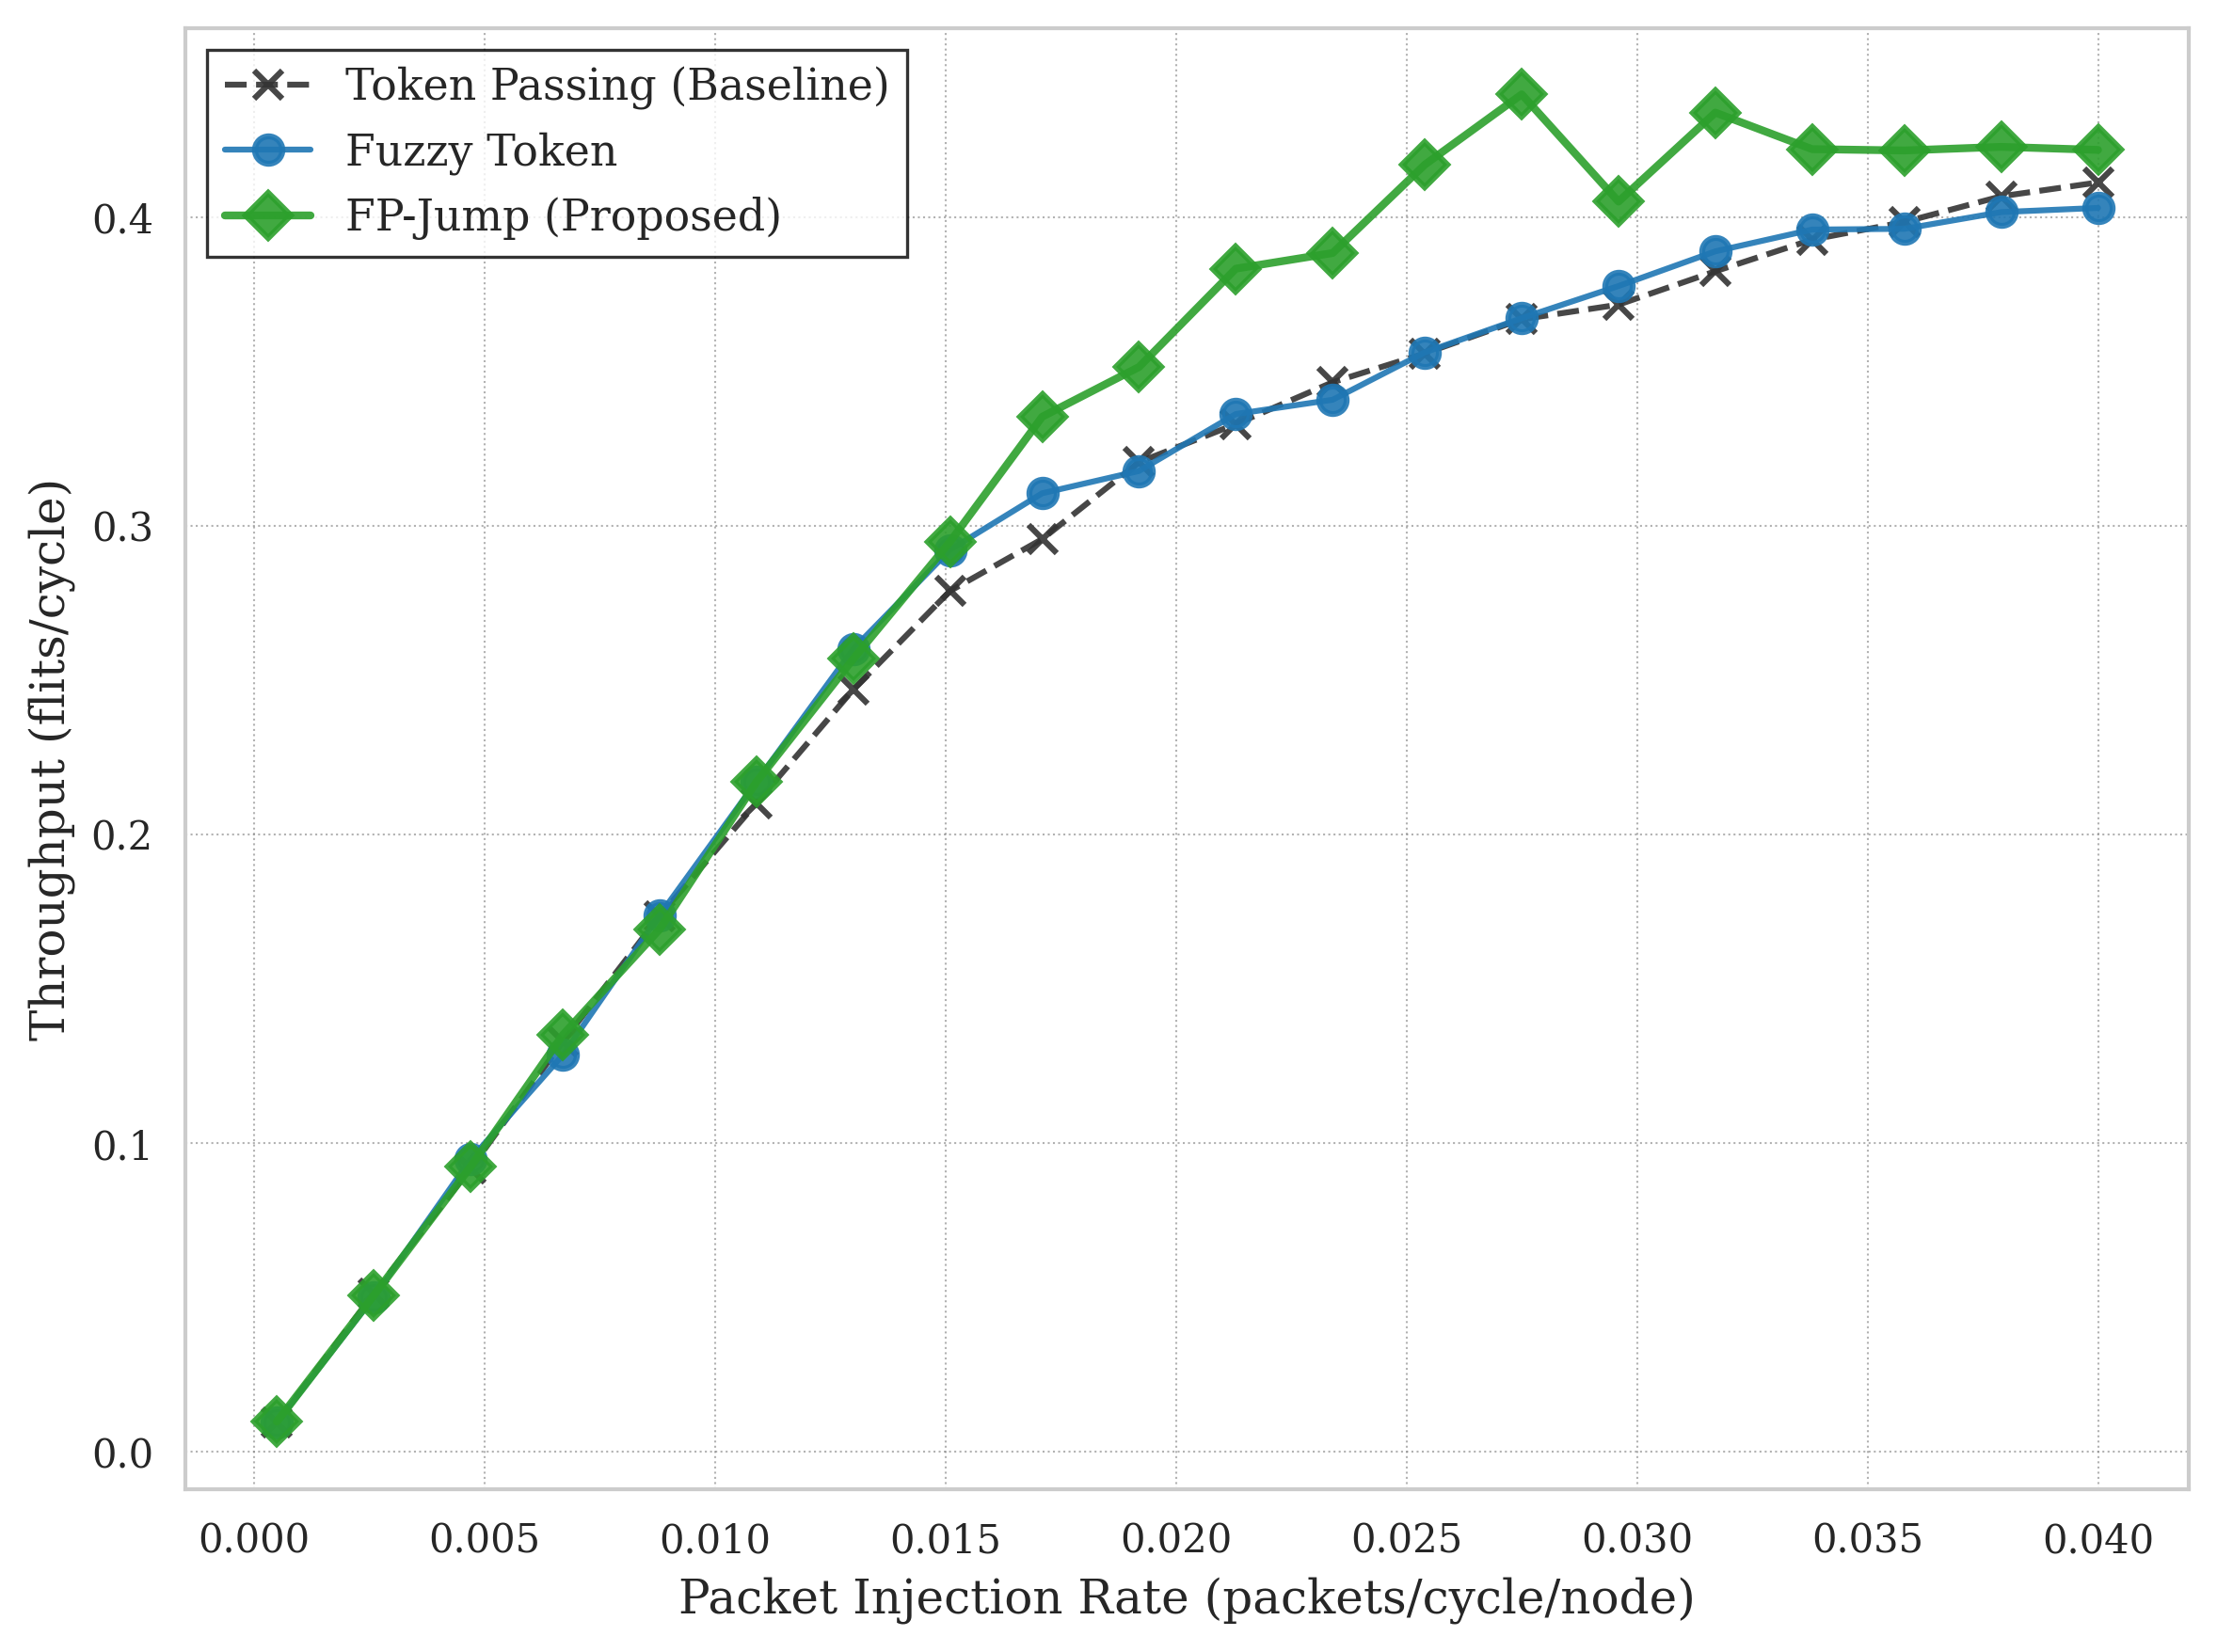

Saved: /Users/nishkarsh/Programming/noxim/paper_results/plots/fig2_latency.png


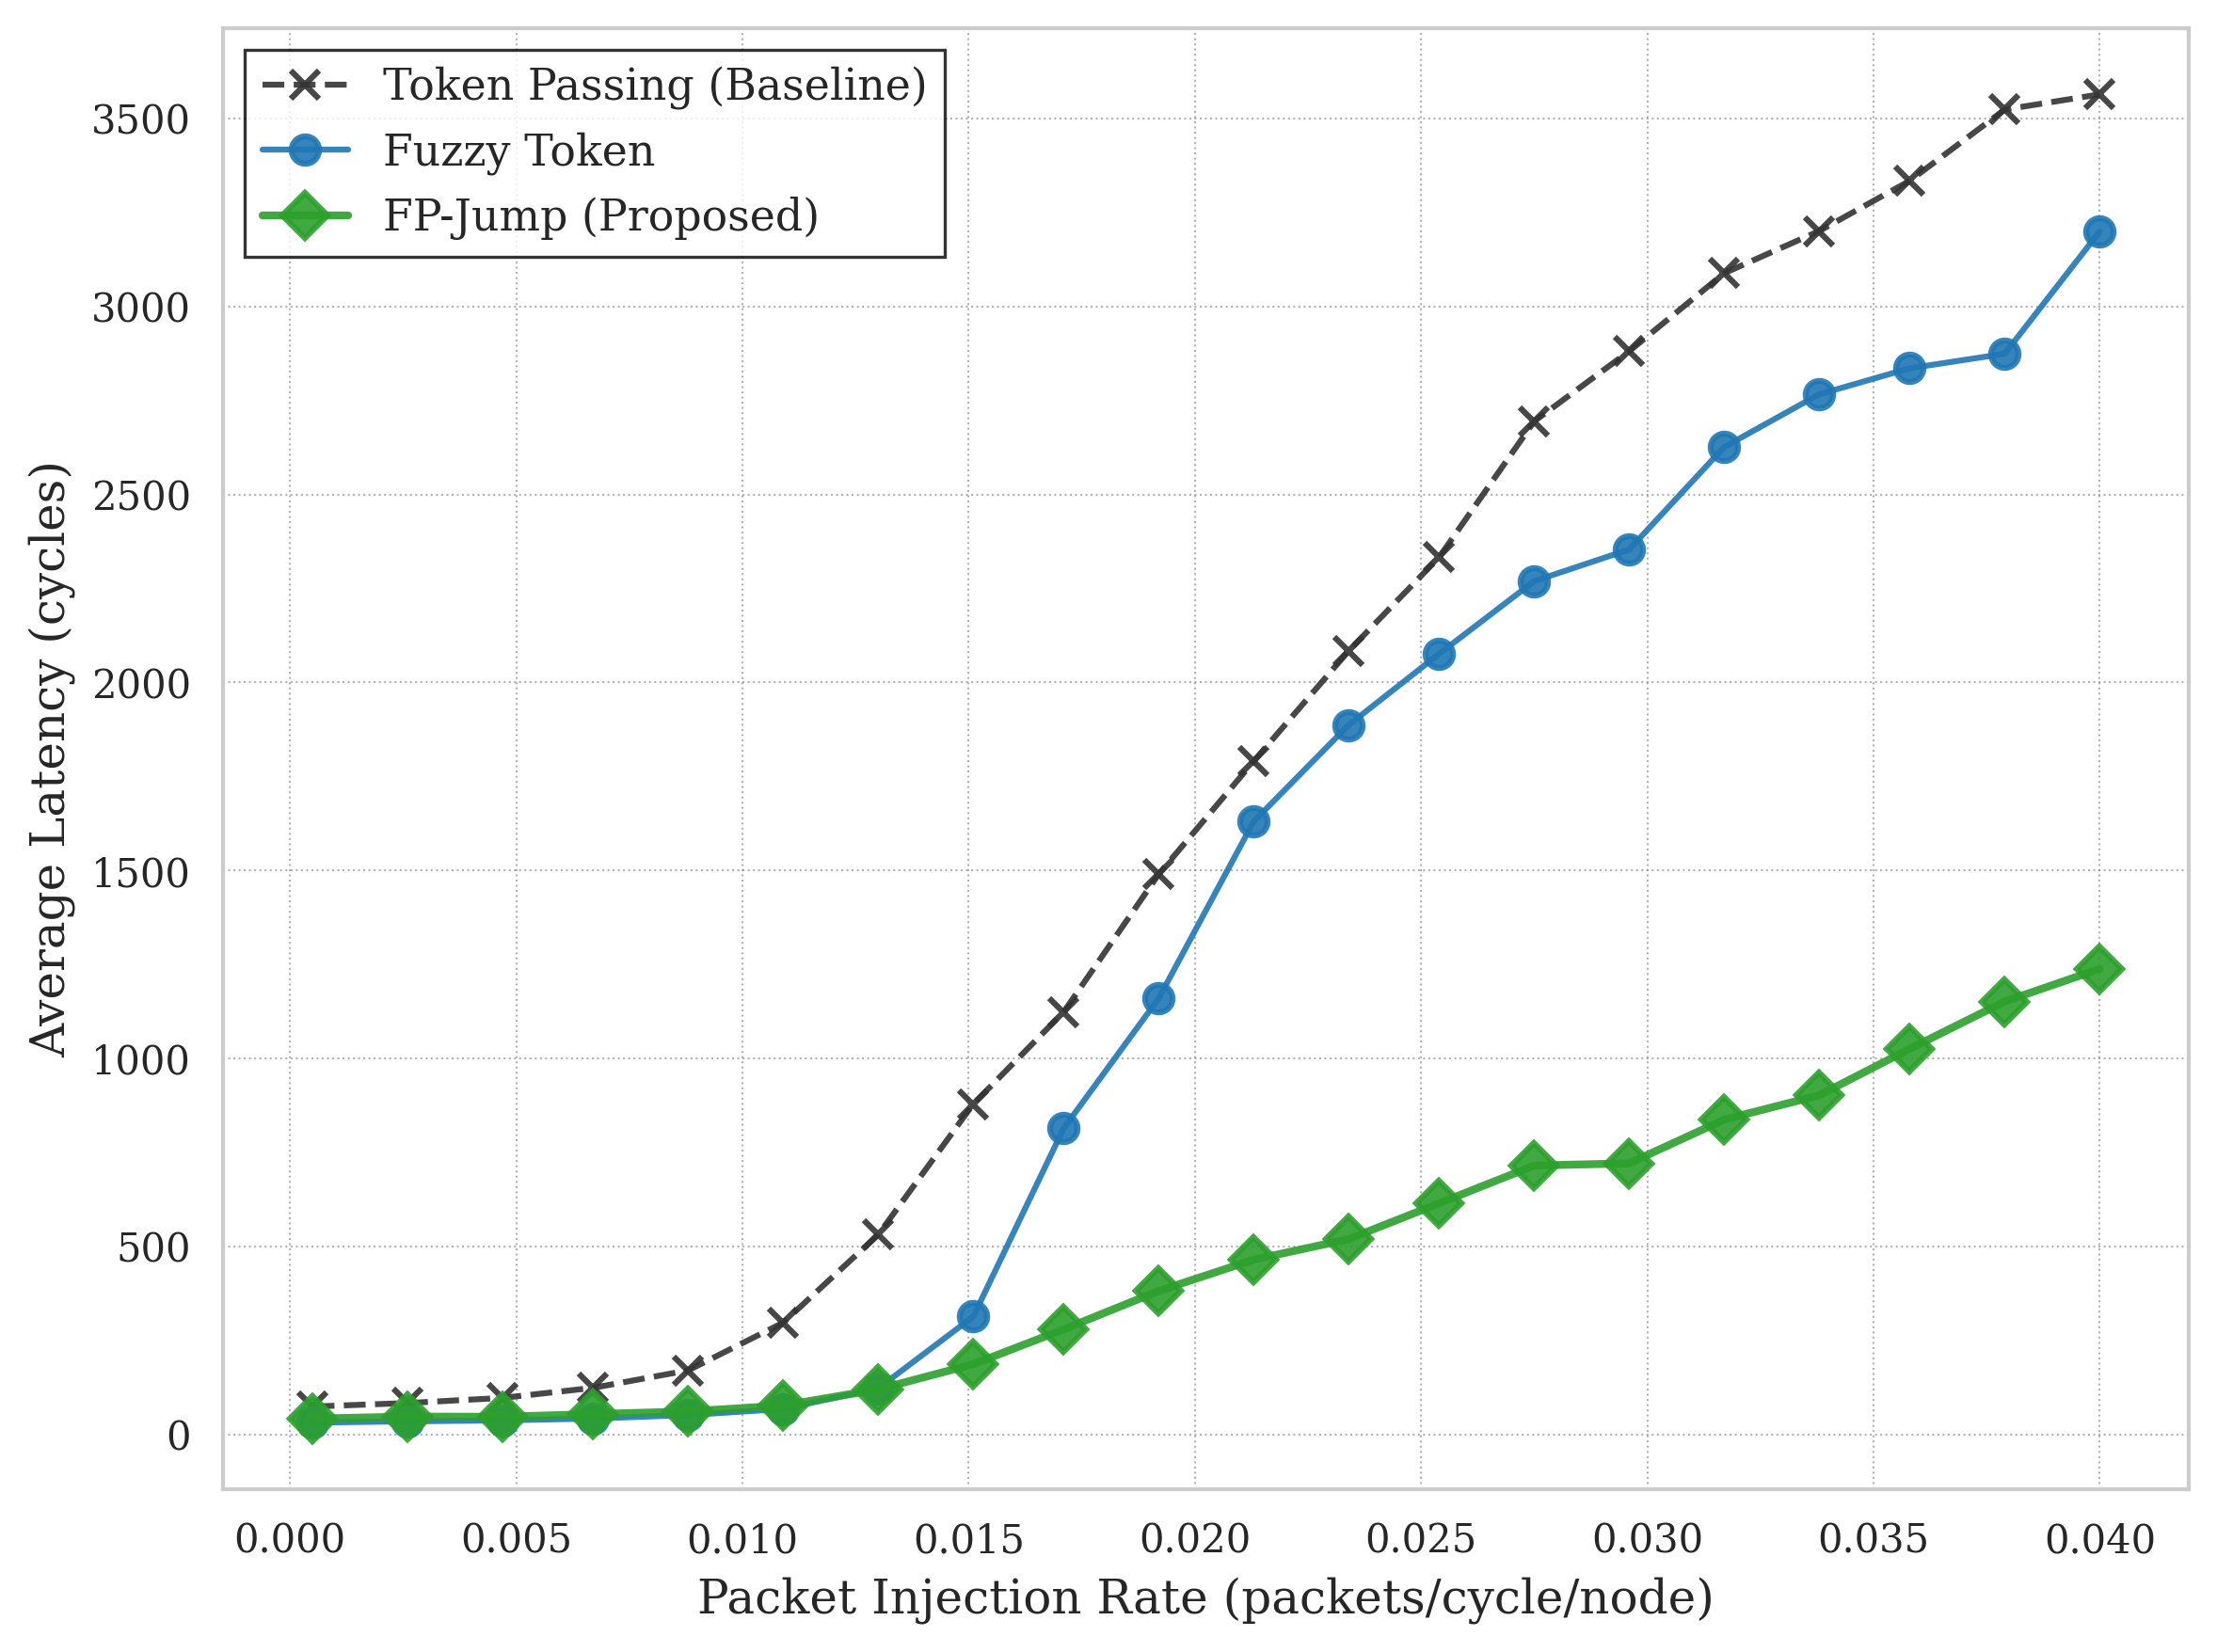

Saved: /Users/nishkarsh/Programming/noxim/paper_results/plots/fig3a_p95.png


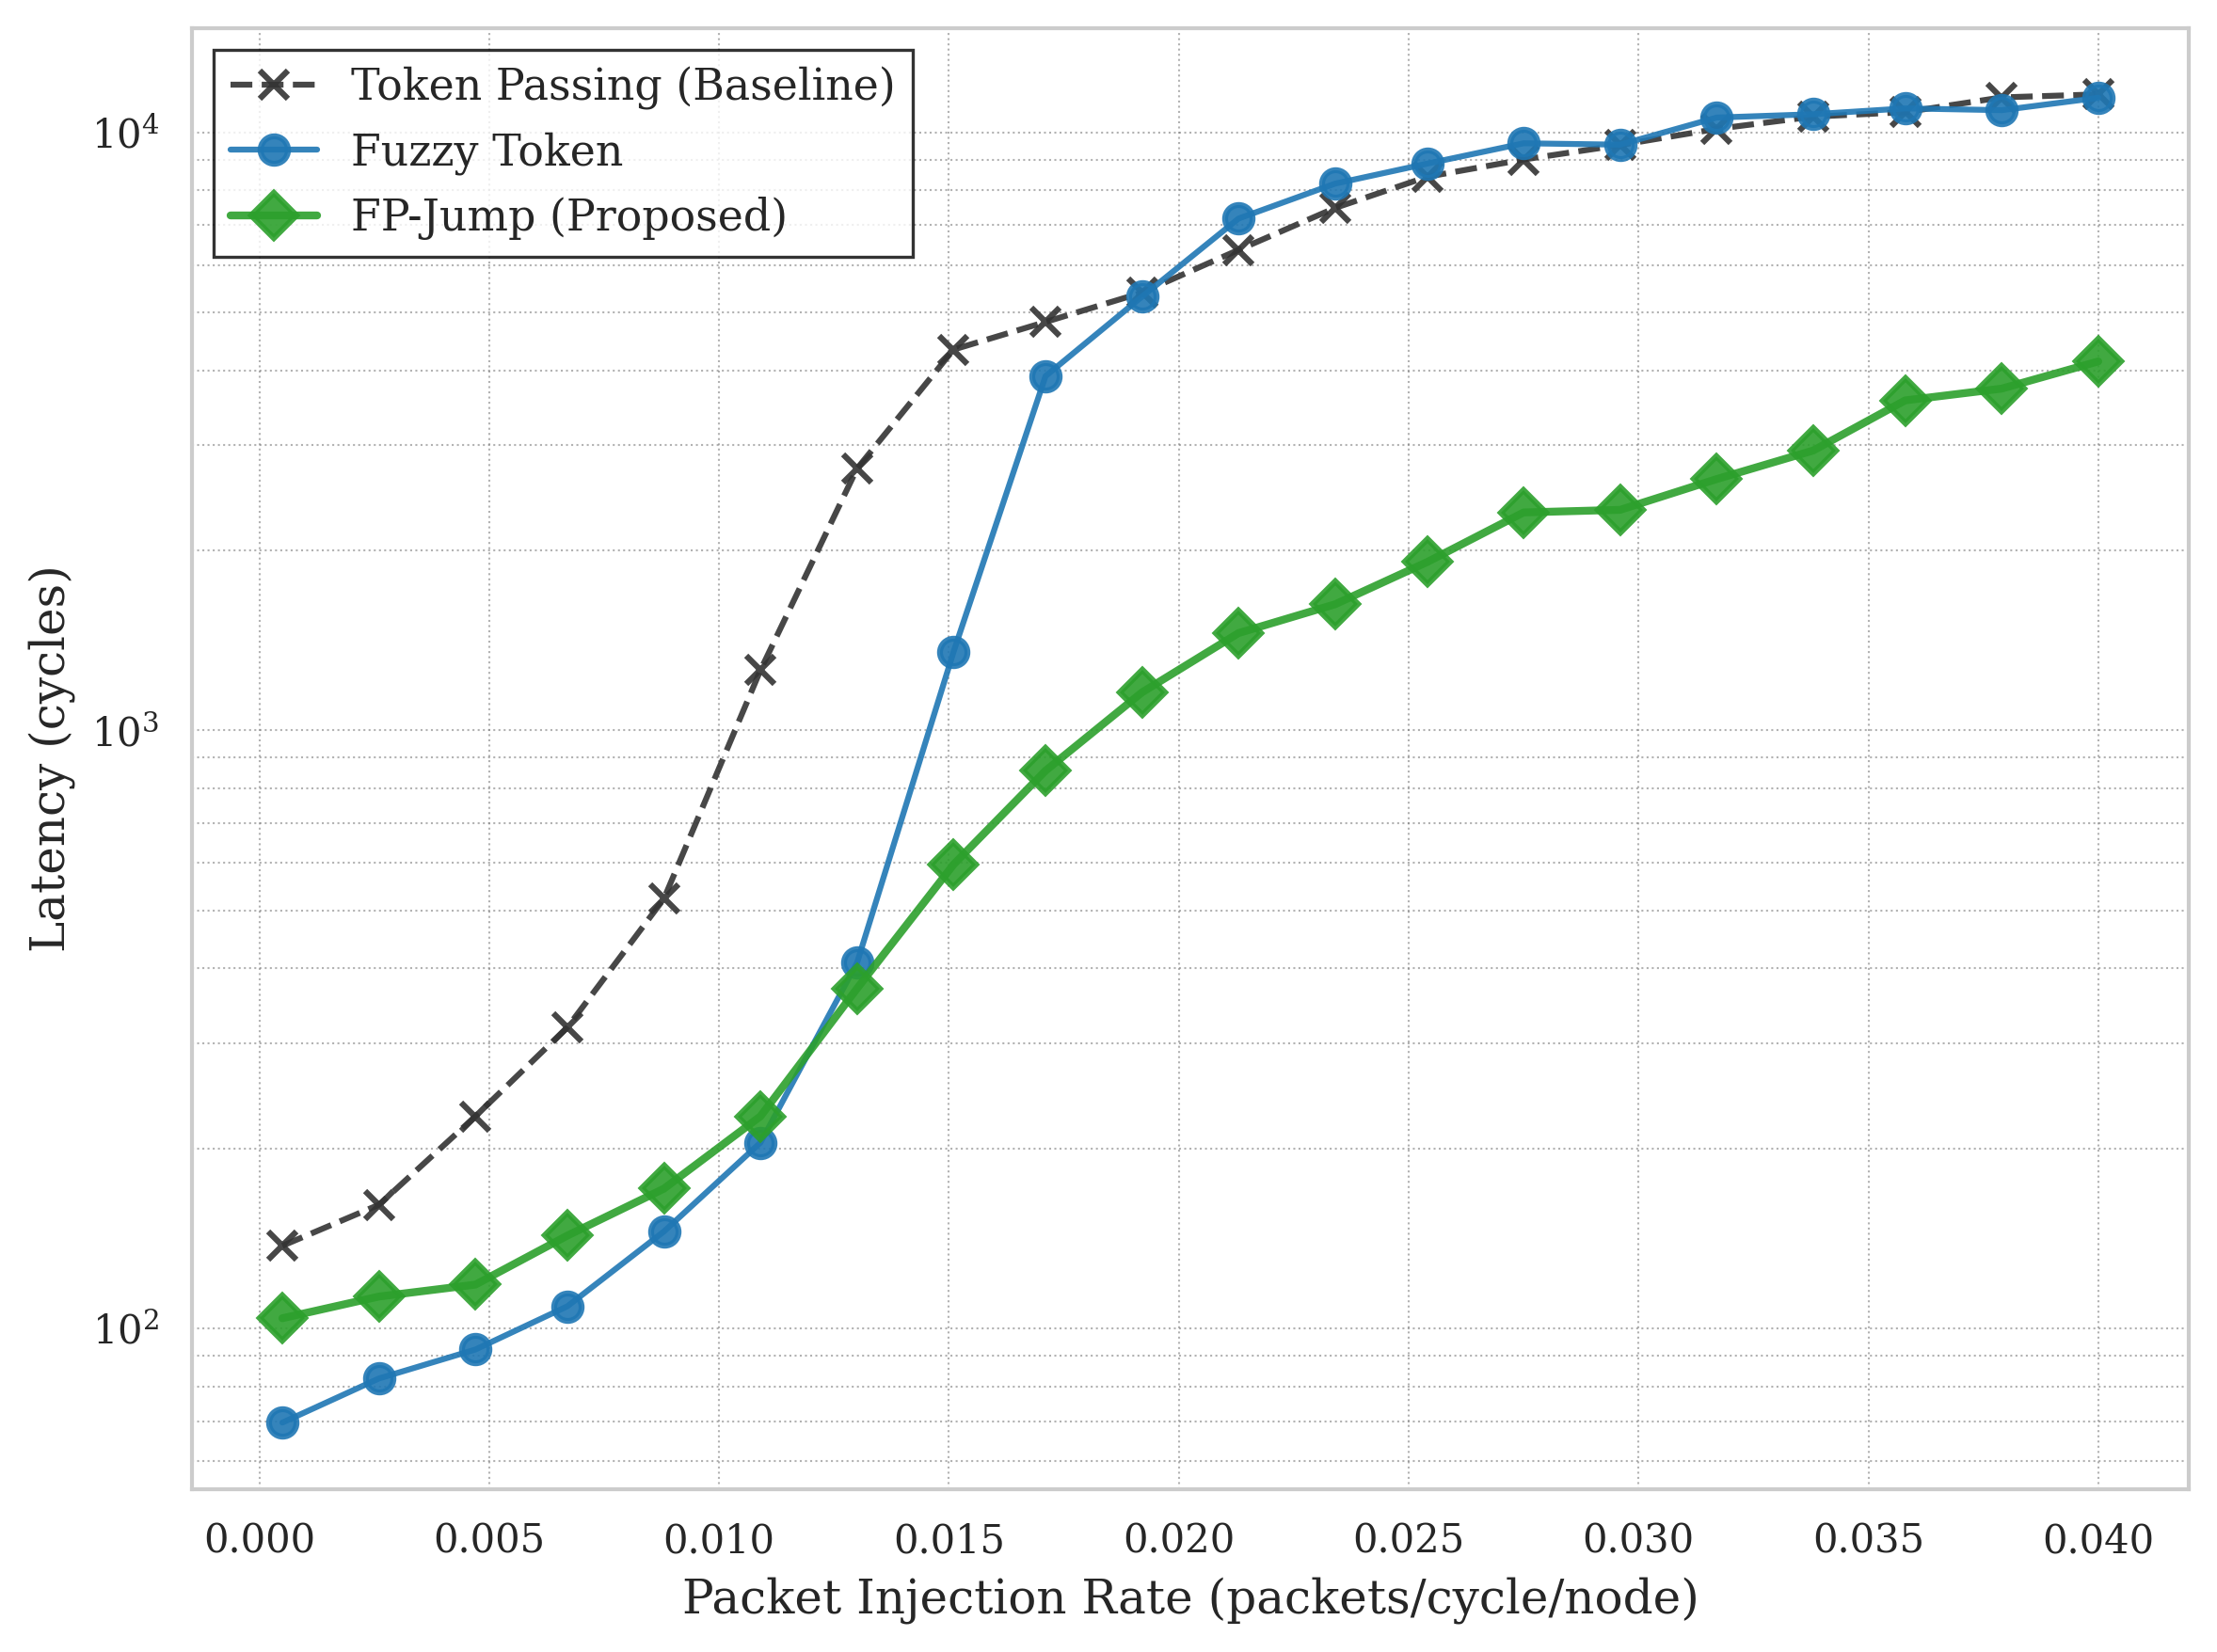

Saved: /Users/nishkarsh/Programming/noxim/paper_results/plots/fig3b_p99.png


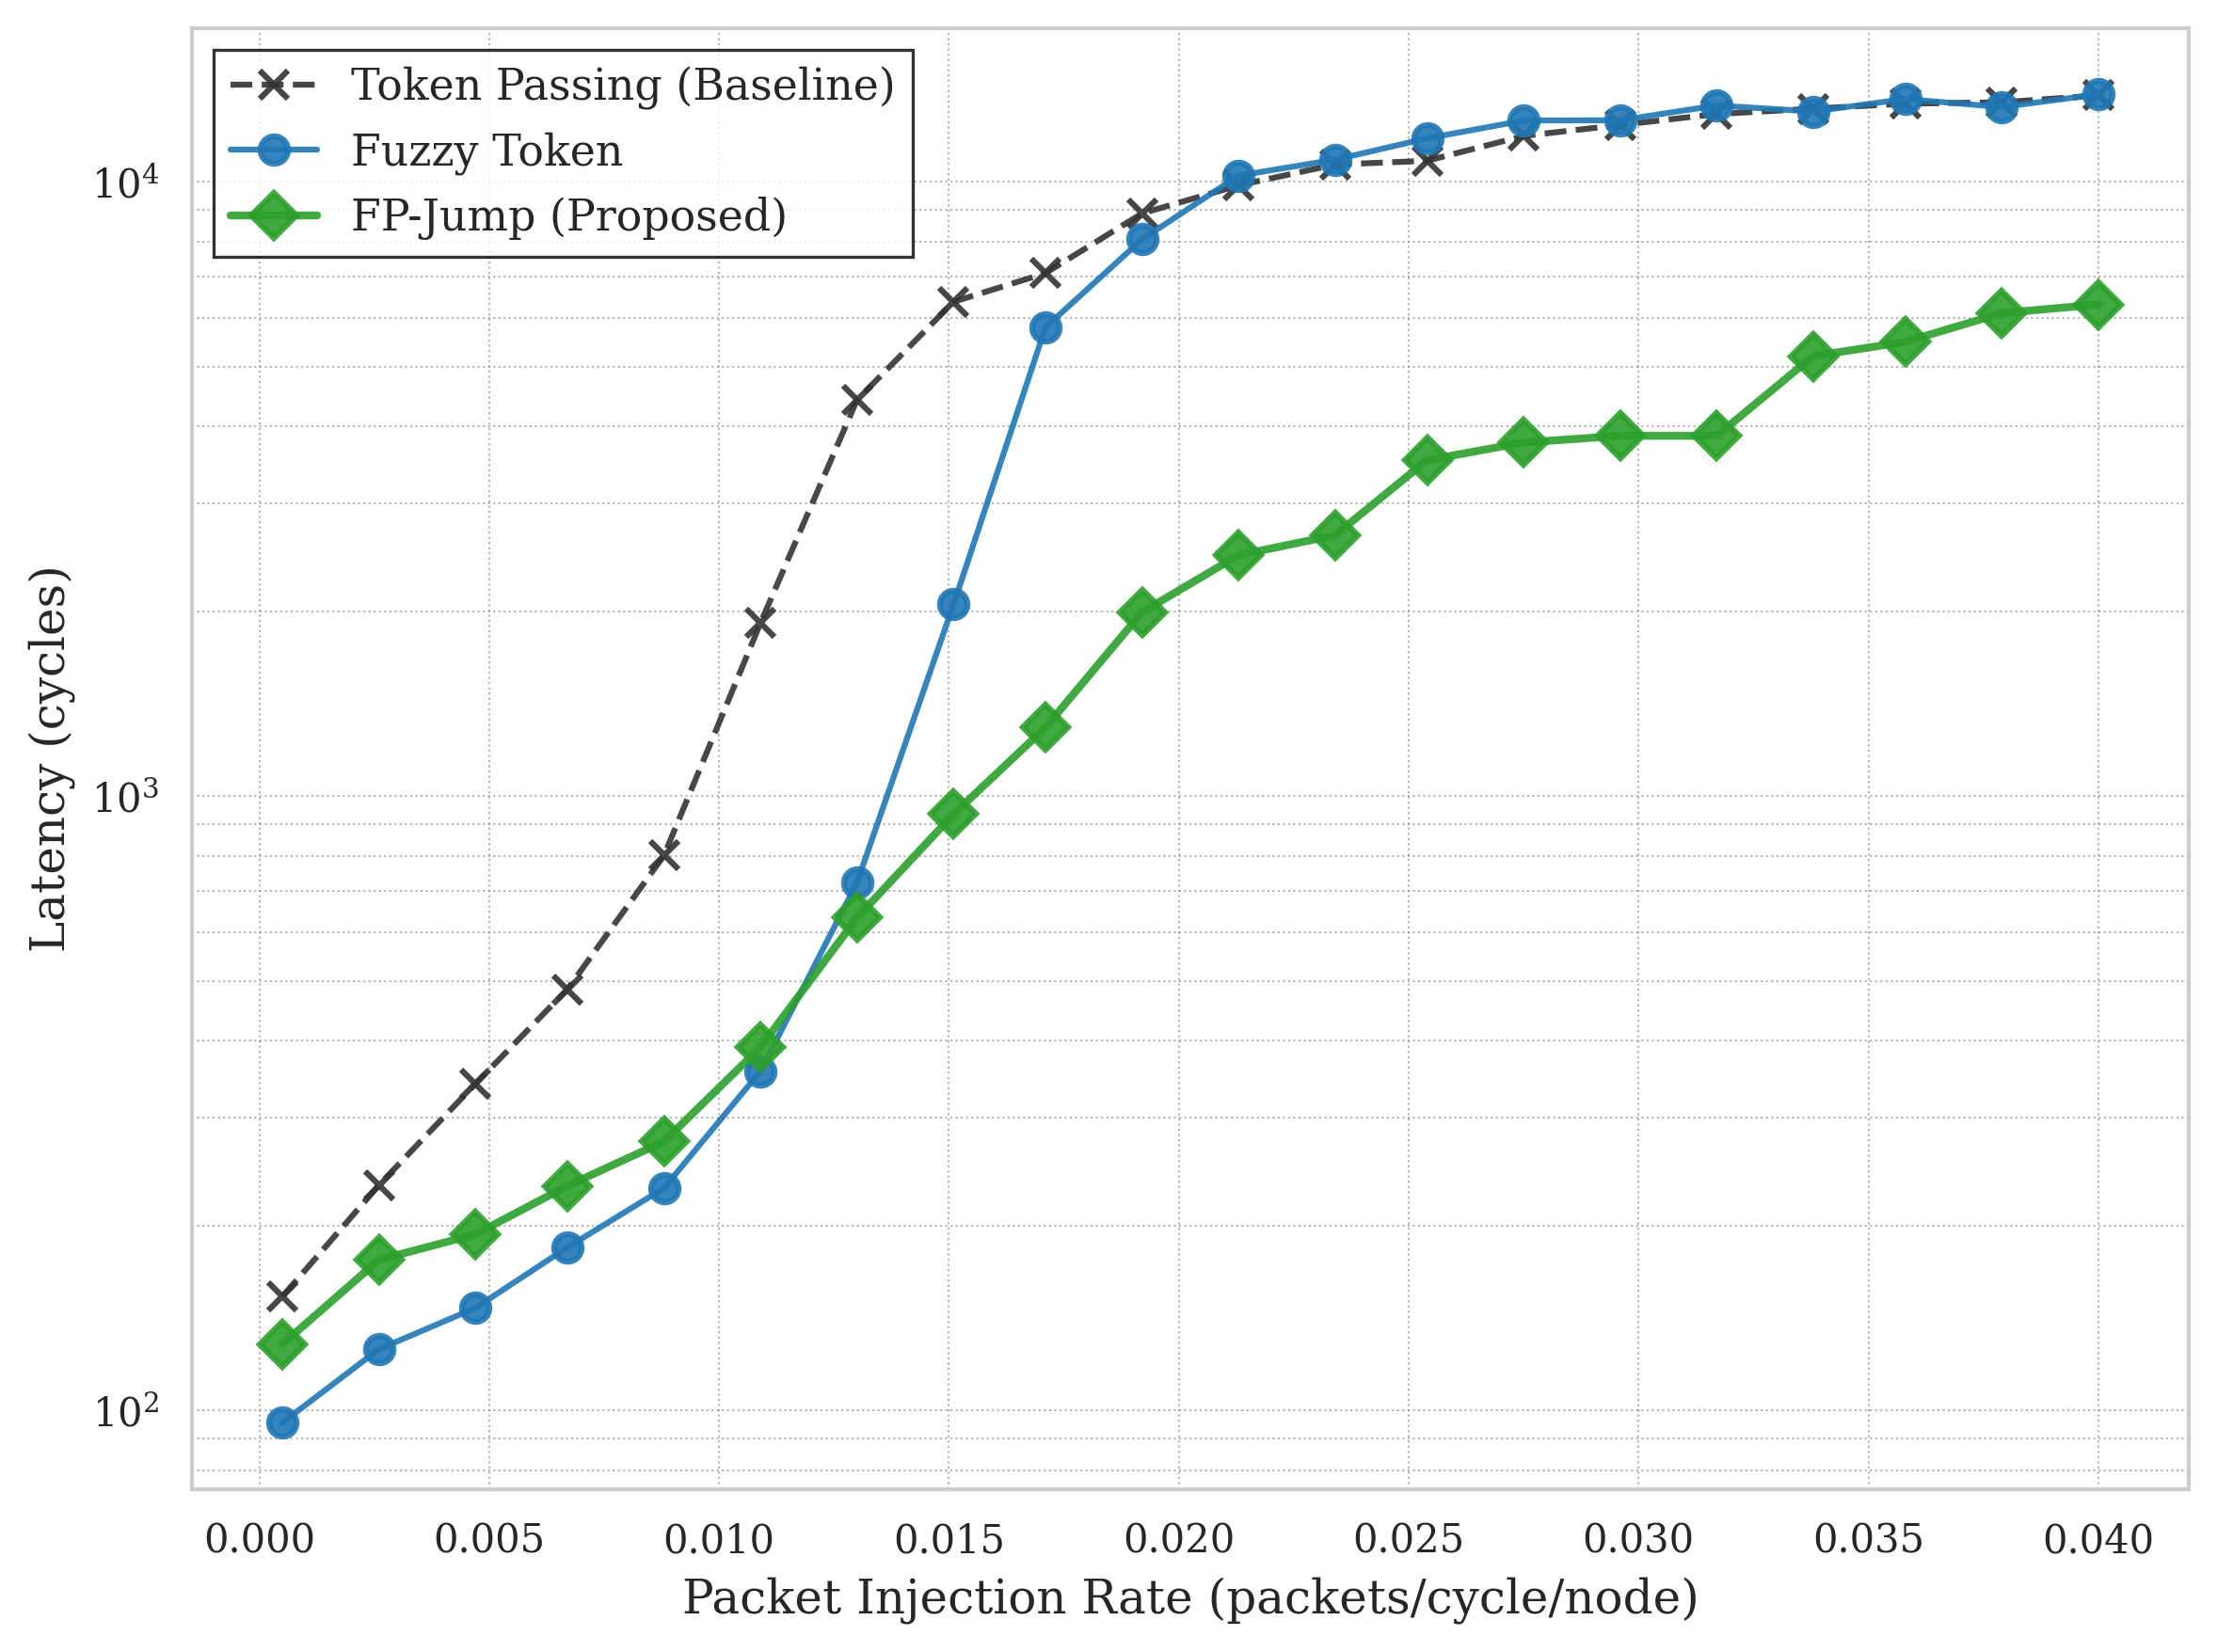

Saved: /Users/nishkarsh/Programming/noxim/paper_results/plots/fig6_energy_dynamic.png


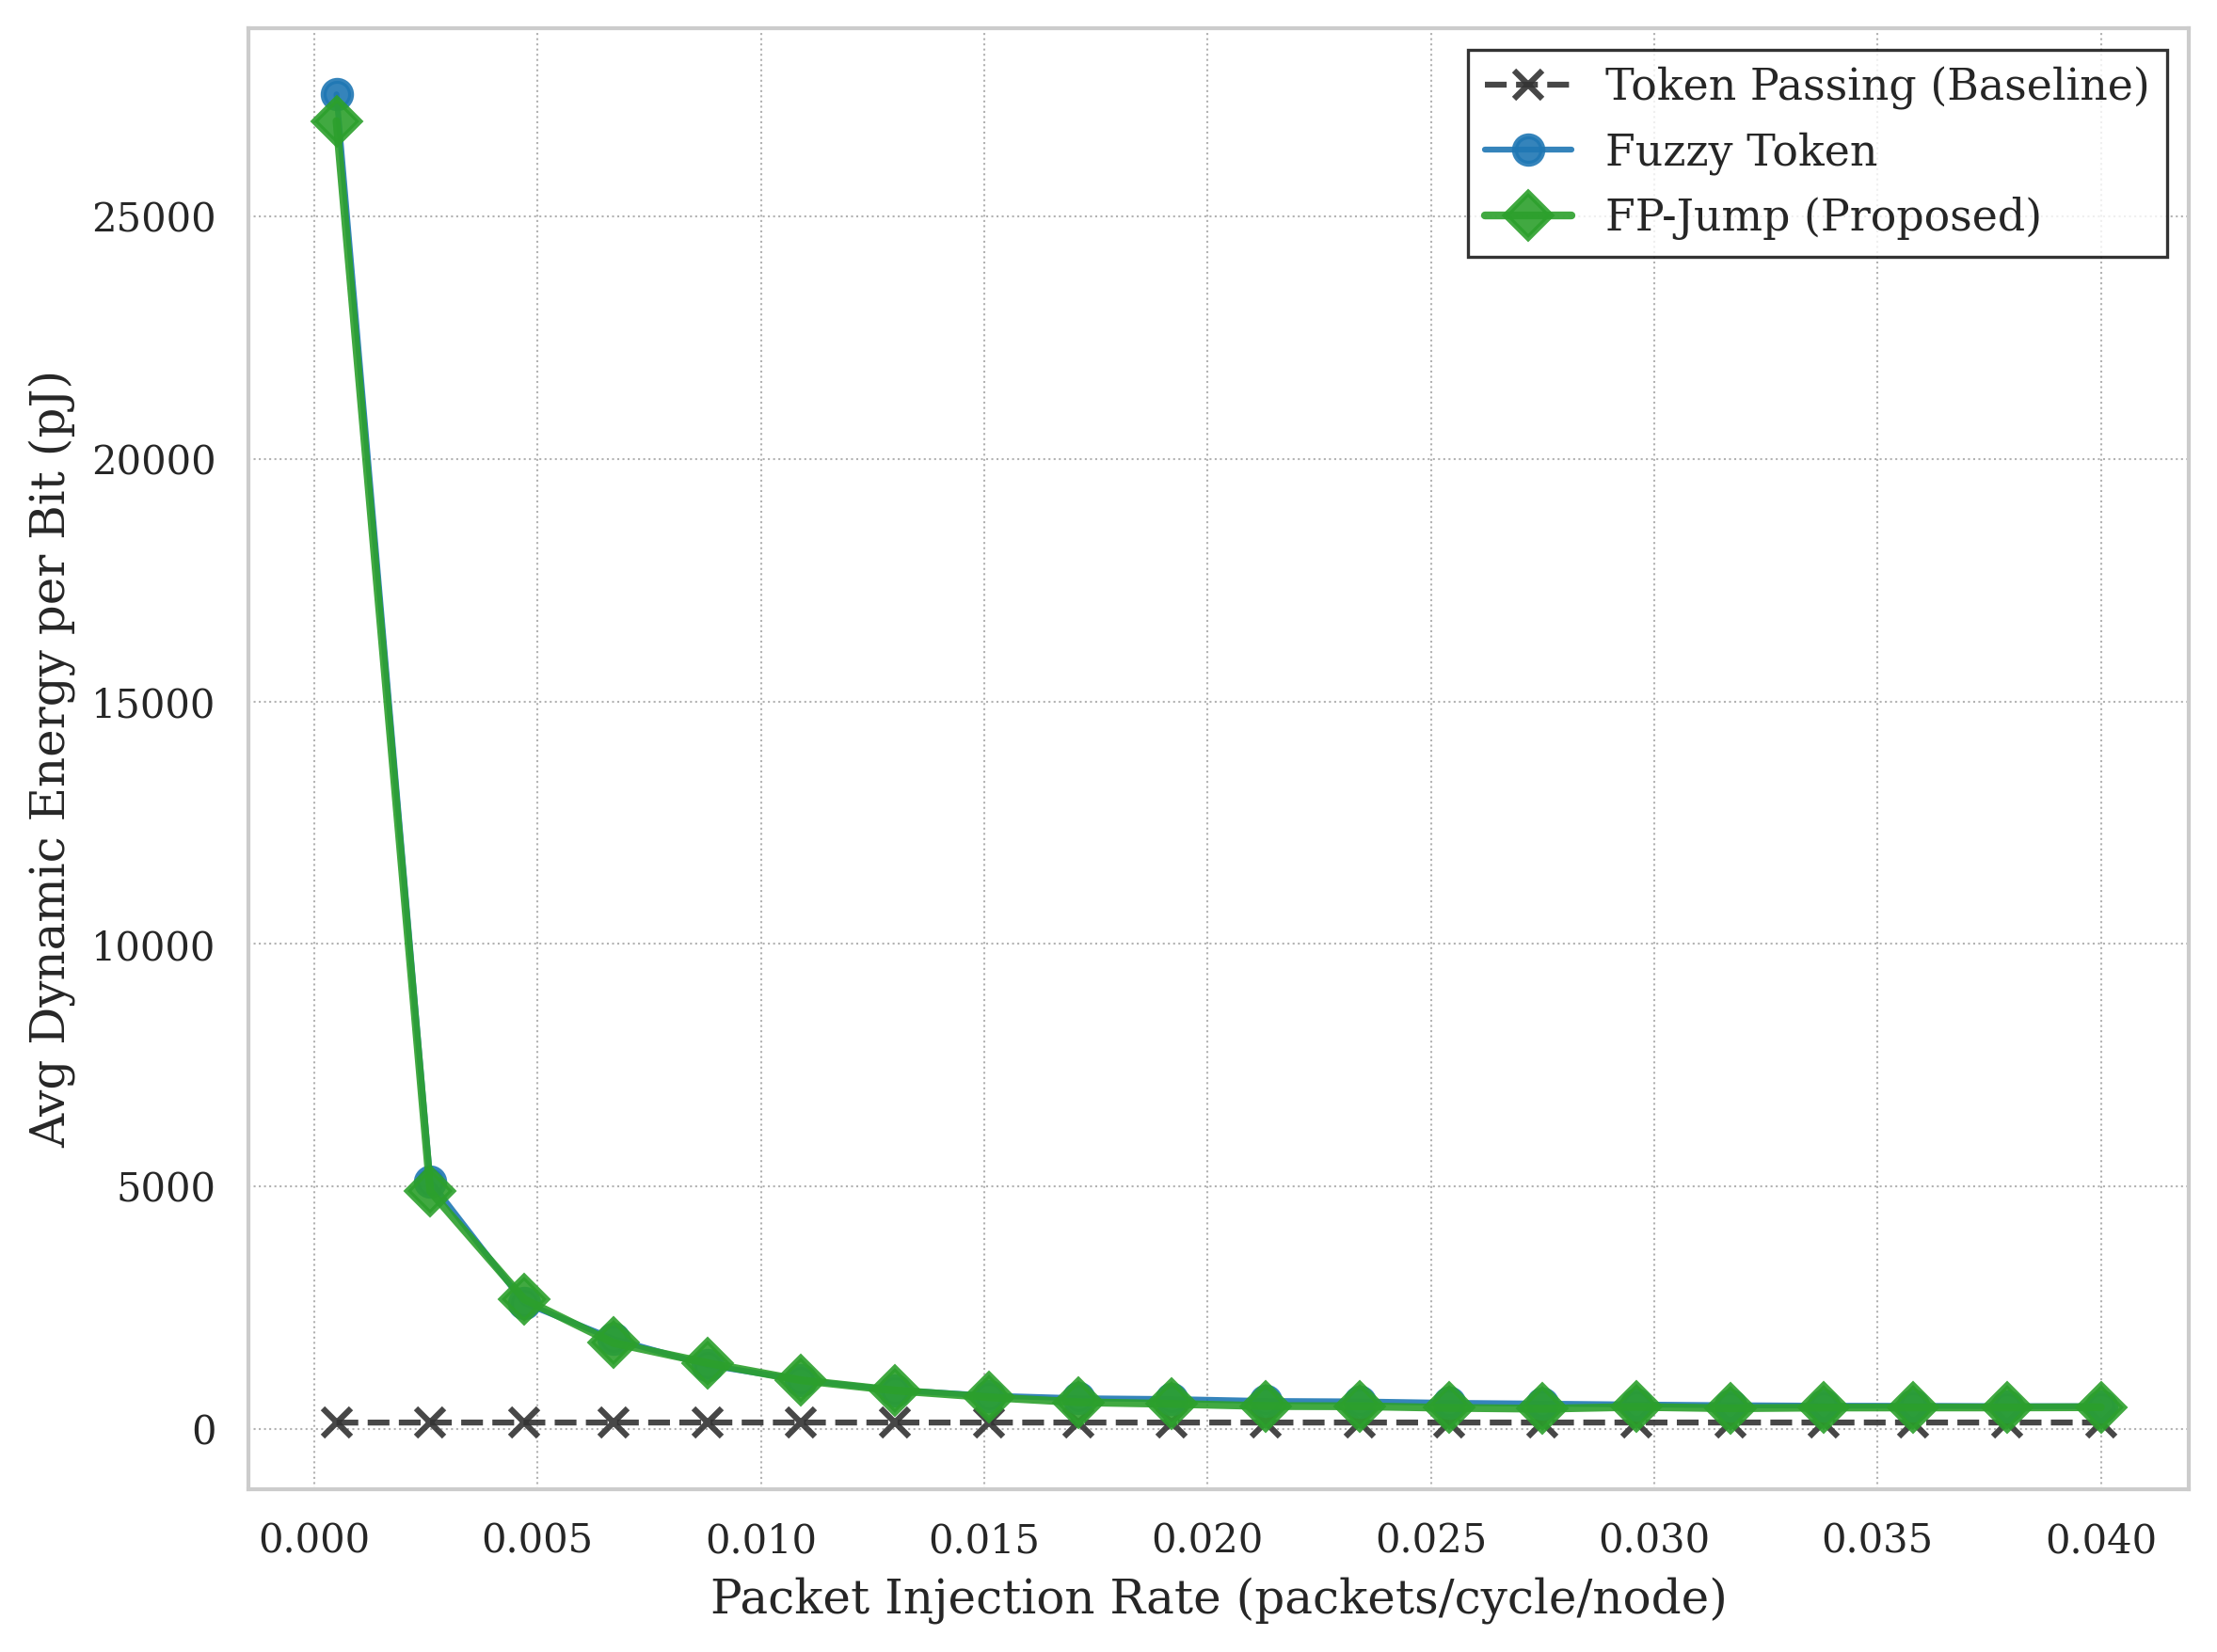

Saved: /Users/nishkarsh/Programming/noxim/paper_results/plots/fig6b_energy_static.png


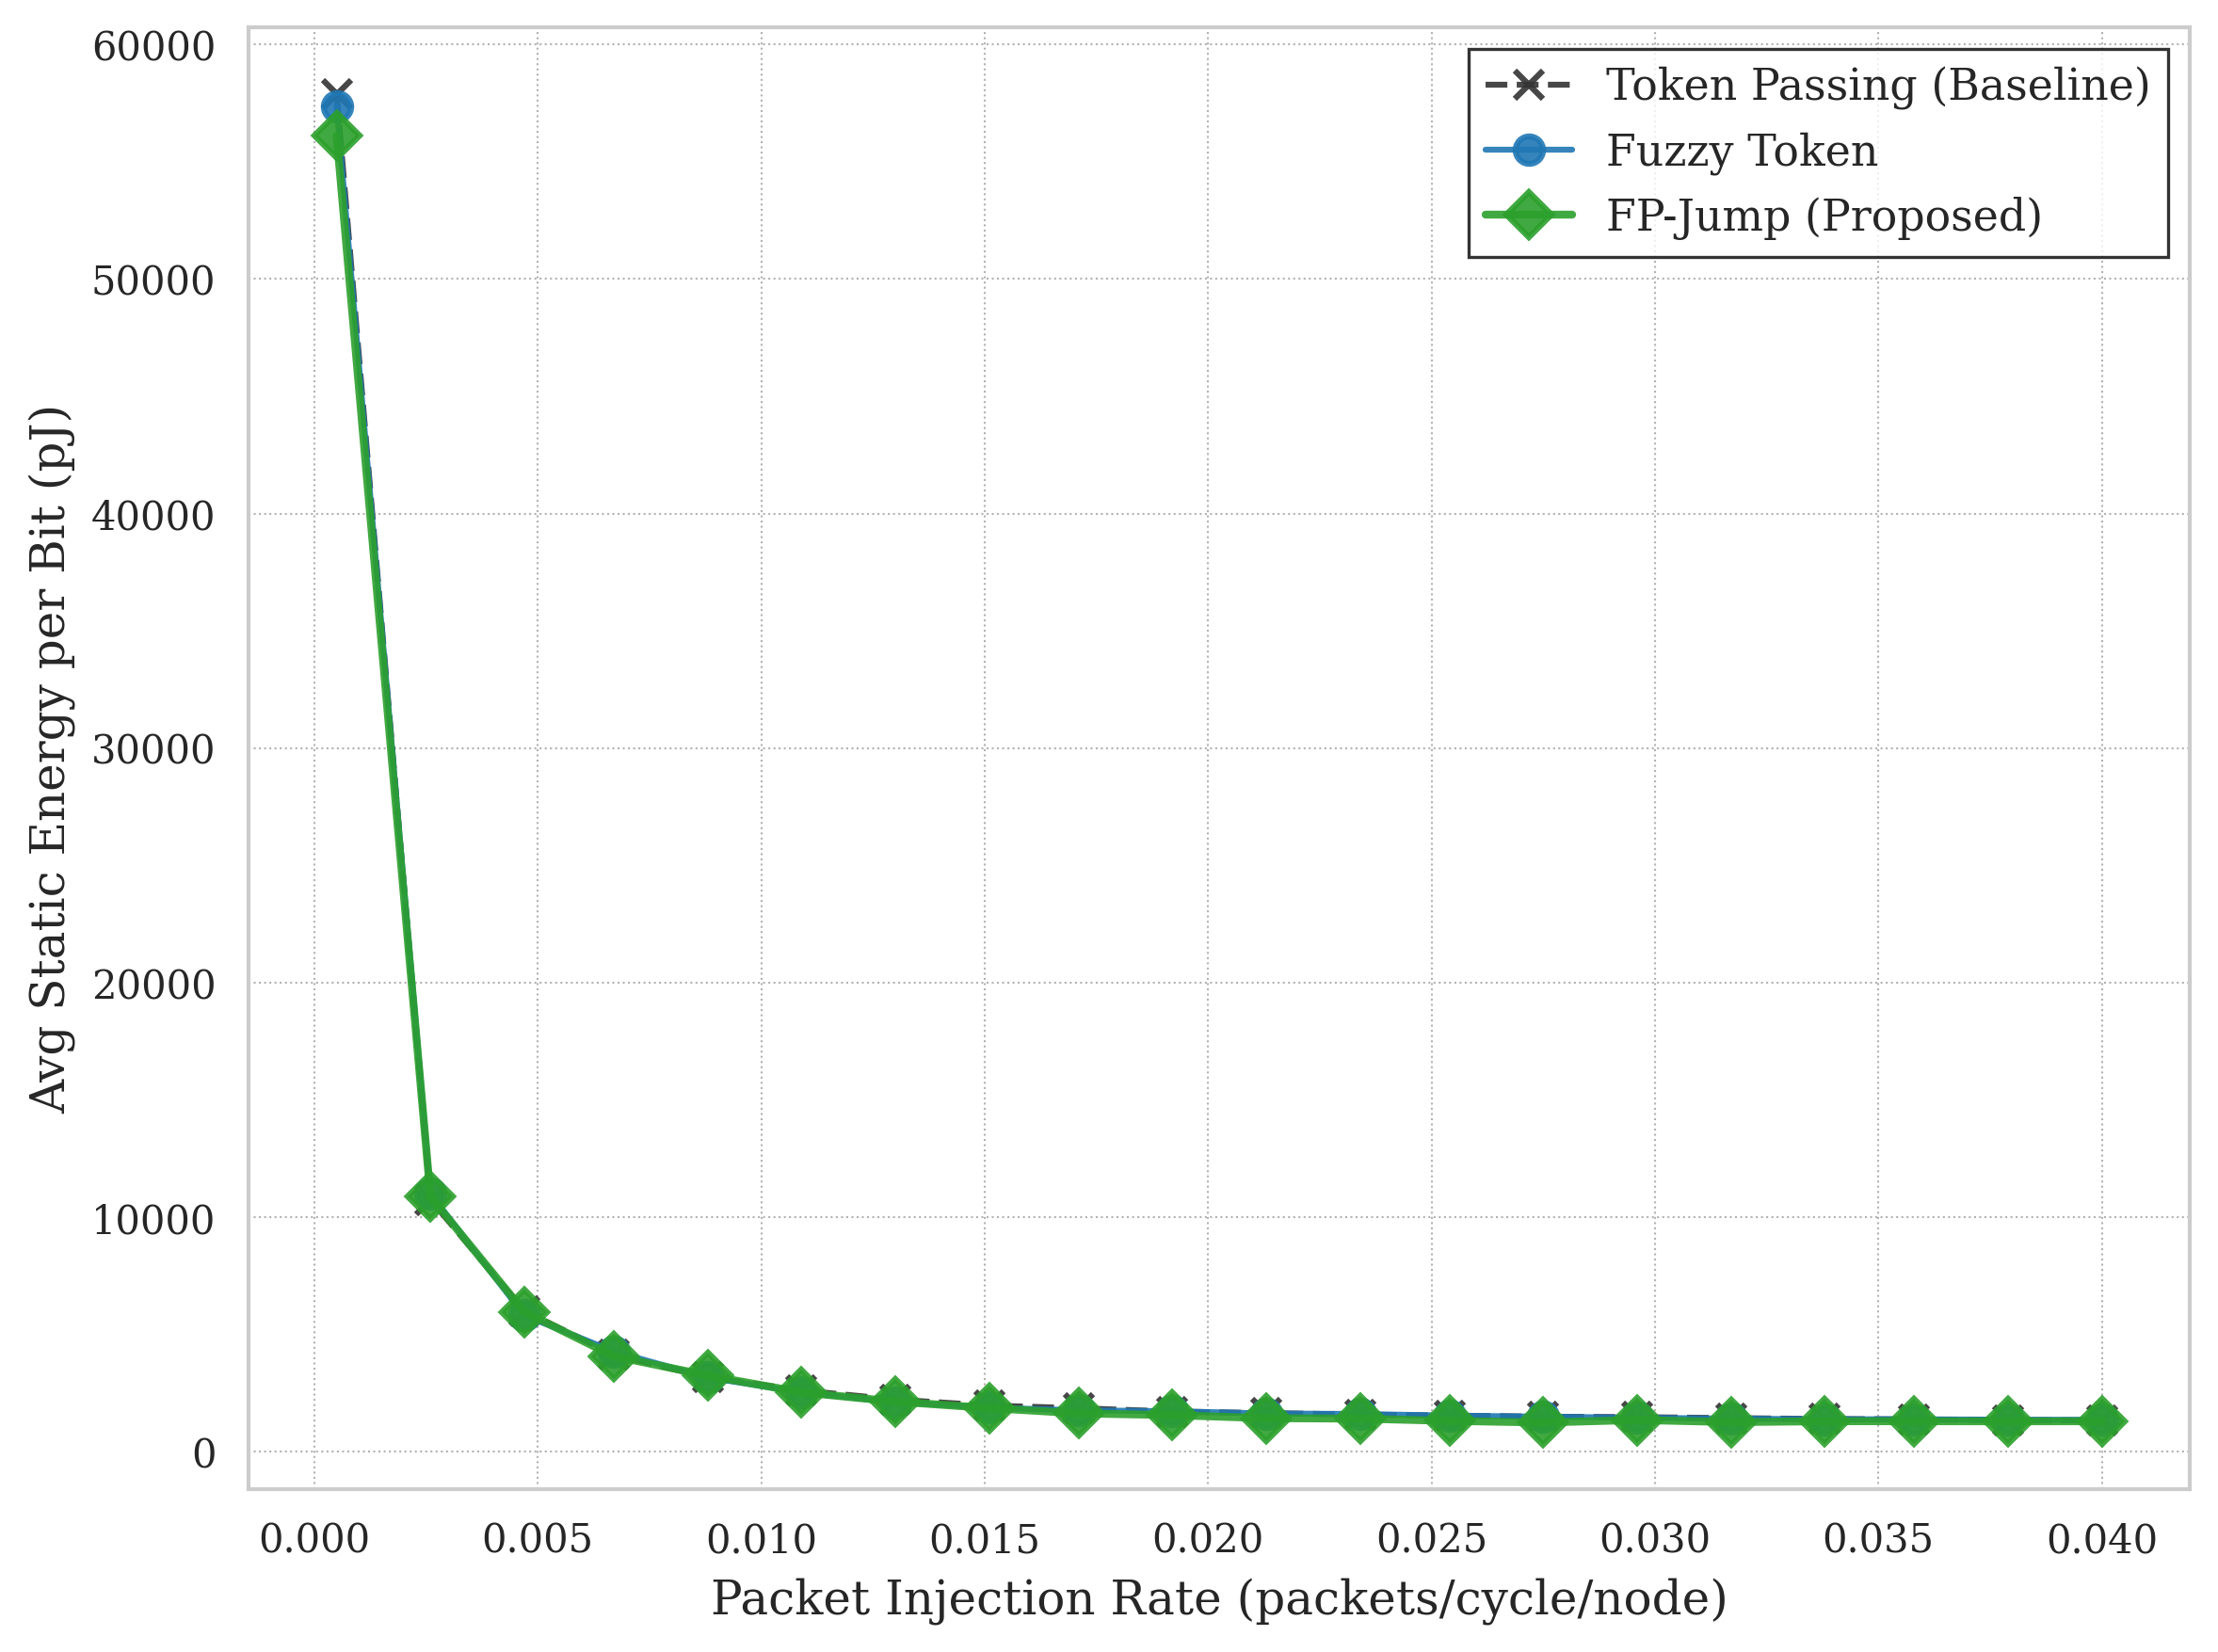

Saved: /Users/nishkarsh/Programming/noxim/paper_results/plots/fig7_rg.png


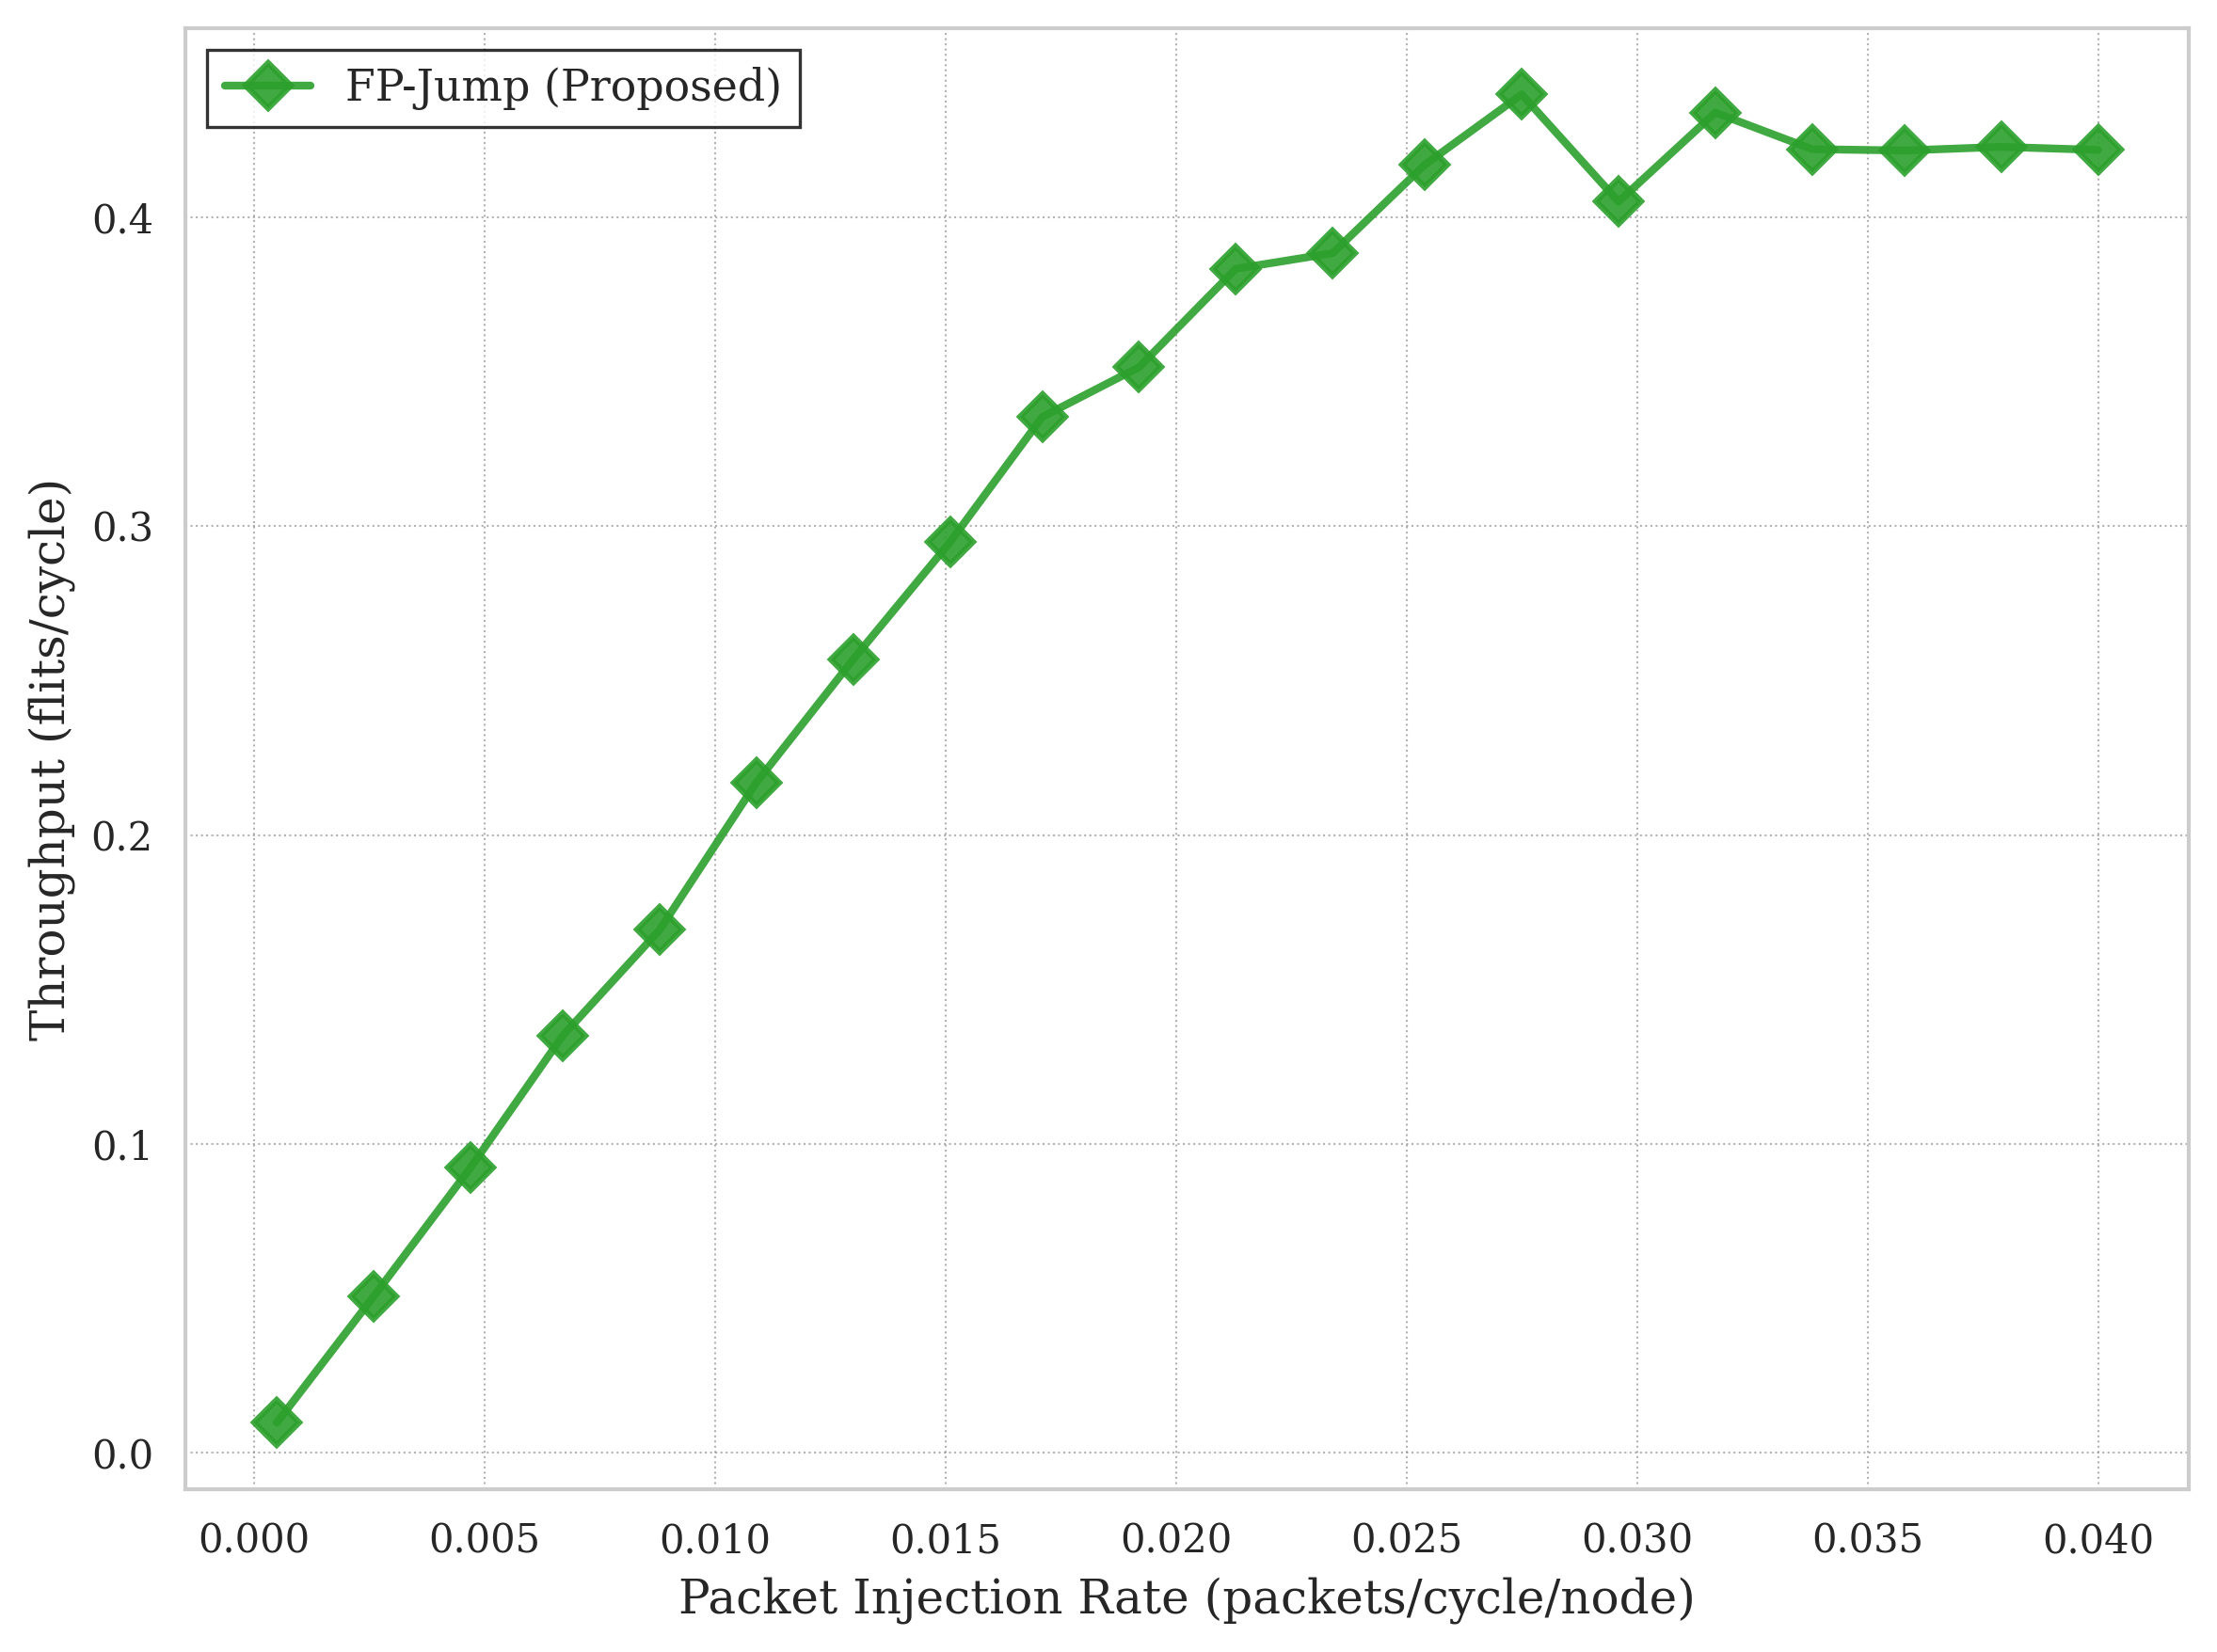

In [71]:
# --- 4. Plotting: PIR Sweep Results ---

if not df_pir.empty:
    # Figure 1: Throughput
    plot_comparisons(df_pir, "pir", "throughput", "Figure 1: Throughput Analysis", "Throughput (flits/cycle)", filename="fig1_throughput.png")

    # Figure 2: Average Latency
    plot_comparisons(df_pir, "pir", "avg_delay", "Figure 2: Average Latency", "Average Latency (cycles)", filename="fig2_latency.png")

    # Figure 3: Tail Latency
    plot_comparisons(df_pir, "pir", "p95_delay", "Figure 3a: 95th Percentile Latency", "Latency (cycles)", log_y=True, filename="fig3a_p95.png")
    plot_comparisons(df_pir, "pir", "p99_delay", "Figure 3b: 99th Percentile Latency", "Latency (cycles)", log_y=True, filename="fig3b_p99.png")

    # Figure 6: Dynamic Energy
    # User requested: "Only plot the dynamic energy" and unit as "avg energy per bit per node"
    # We interpret this as global Avg Energy per bit.
    plot_comparisons(df_pir, "pir", "dynamic_per_bit_pJ", "Figure 6: Dynamic Energy Efficiency", "Avg Dynamic Energy per Bit (pJ)", filename="fig6_energy_dynamic.png")

    # Figure 6b: Static Energy
    # User requested: "separate plot for just static energy"
    plot_comparisons(df_pir, "pir", "static_per_bit_pJ", "Figure 6b: Static Energy Efficiency", "Avg Static Energy per Bit (pJ)", filename="fig6b_energy_static.png")

    # Figure 7: Upper Bound
    df_rg = df_pir[df_pir["protocol"].isin(["FP-Jump", "FP-Jump + RG"])]
    if not df_rg.empty:
        plot_comparisons(df_rg, "pir", "throughput", "Figure 7: Impact of Readiness Gating", "Throughput (flits/cycle)", filename="fig7_rg.png")
else:
    print("No data available to plot.")

In [56]:
# --- 5. Simulation: Hurst Sweep (Multi-Seed) ---
# Sensitivity to Temporal Burstiness (H)

HURST_LIST = [round(x, 2) for x in np.linspace(0.5, 0.9, 5)]
FIXED_PIR_HURST = 0.025
# Reuse NUM_SEEDS and SEEDS from previous section

RESULTS_HURST = []
print("Running Hurst Sweep with parallel execution...")

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    for protocol_name, src_config in PROTOCOLS.items():
        if protocol_name == "FP-Jump + RG": continue 
        
        print(f"  Protocol: {protocol_name}")
        
        # Load base config
        with open(src_config, 'r') as f:
            base_cfg = yaml.safe_load(f)
            
        for h in HURST_LIST:
            futures = []
            for s in SEEDS:
                # Create temp config for this seed/param combination
                cfg = base_cfg.copy()
                cfg['traffic_soteriou_sigma'] = 3.0  # Fixed high sigma
                cfg['traffic_soteriou_hurst'] = float(h)
                
                # Unique filename is crucial for parallel access
                unique_name = f"hurst_{protocol_name.replace(' ', '')}_H{h}_S{s}.yaml"
                
                # Submit helper which handles file I/O safely
                futures.append(executor.submit(run_with_temp_config, cfg, unique_name, s, FIXED_PIR_HURST))
                
            runs = [f.result() for f in futures]
            
            agg = aggregate_runs(runs)
            entry = {
                "protocol": protocol_name,
                "hurst": h,
                "avg_delay": agg.get("global_average_delay"),
                "throughput": agg.get("network_throughput"), 
                "energy_J": agg.get("total_energy"),
                "energy_per_pkt": agg.get("energy_per_pkt"),
                "p95_delay": agg.get("p95_delay"),
                "p99_delay": agg.get("p99_delay"),
                "pkts": agg.get("received_packets")
            }
            RESULTS_HURST.append(entry)
        
df_hurst = pd.DataFrame(RESULTS_HURST)
print("Hurst Sweep Complete.")

Running Hurst Sweep with parallel execution...
  Protocol: Token Passing
  Protocol: Fuzzy Token
  Protocol: FP-Jump
Hurst Sweep Complete.


Saved: /Users/nishkarsh/Programming/noxim/paper_results/plots/fig4_hurst.png


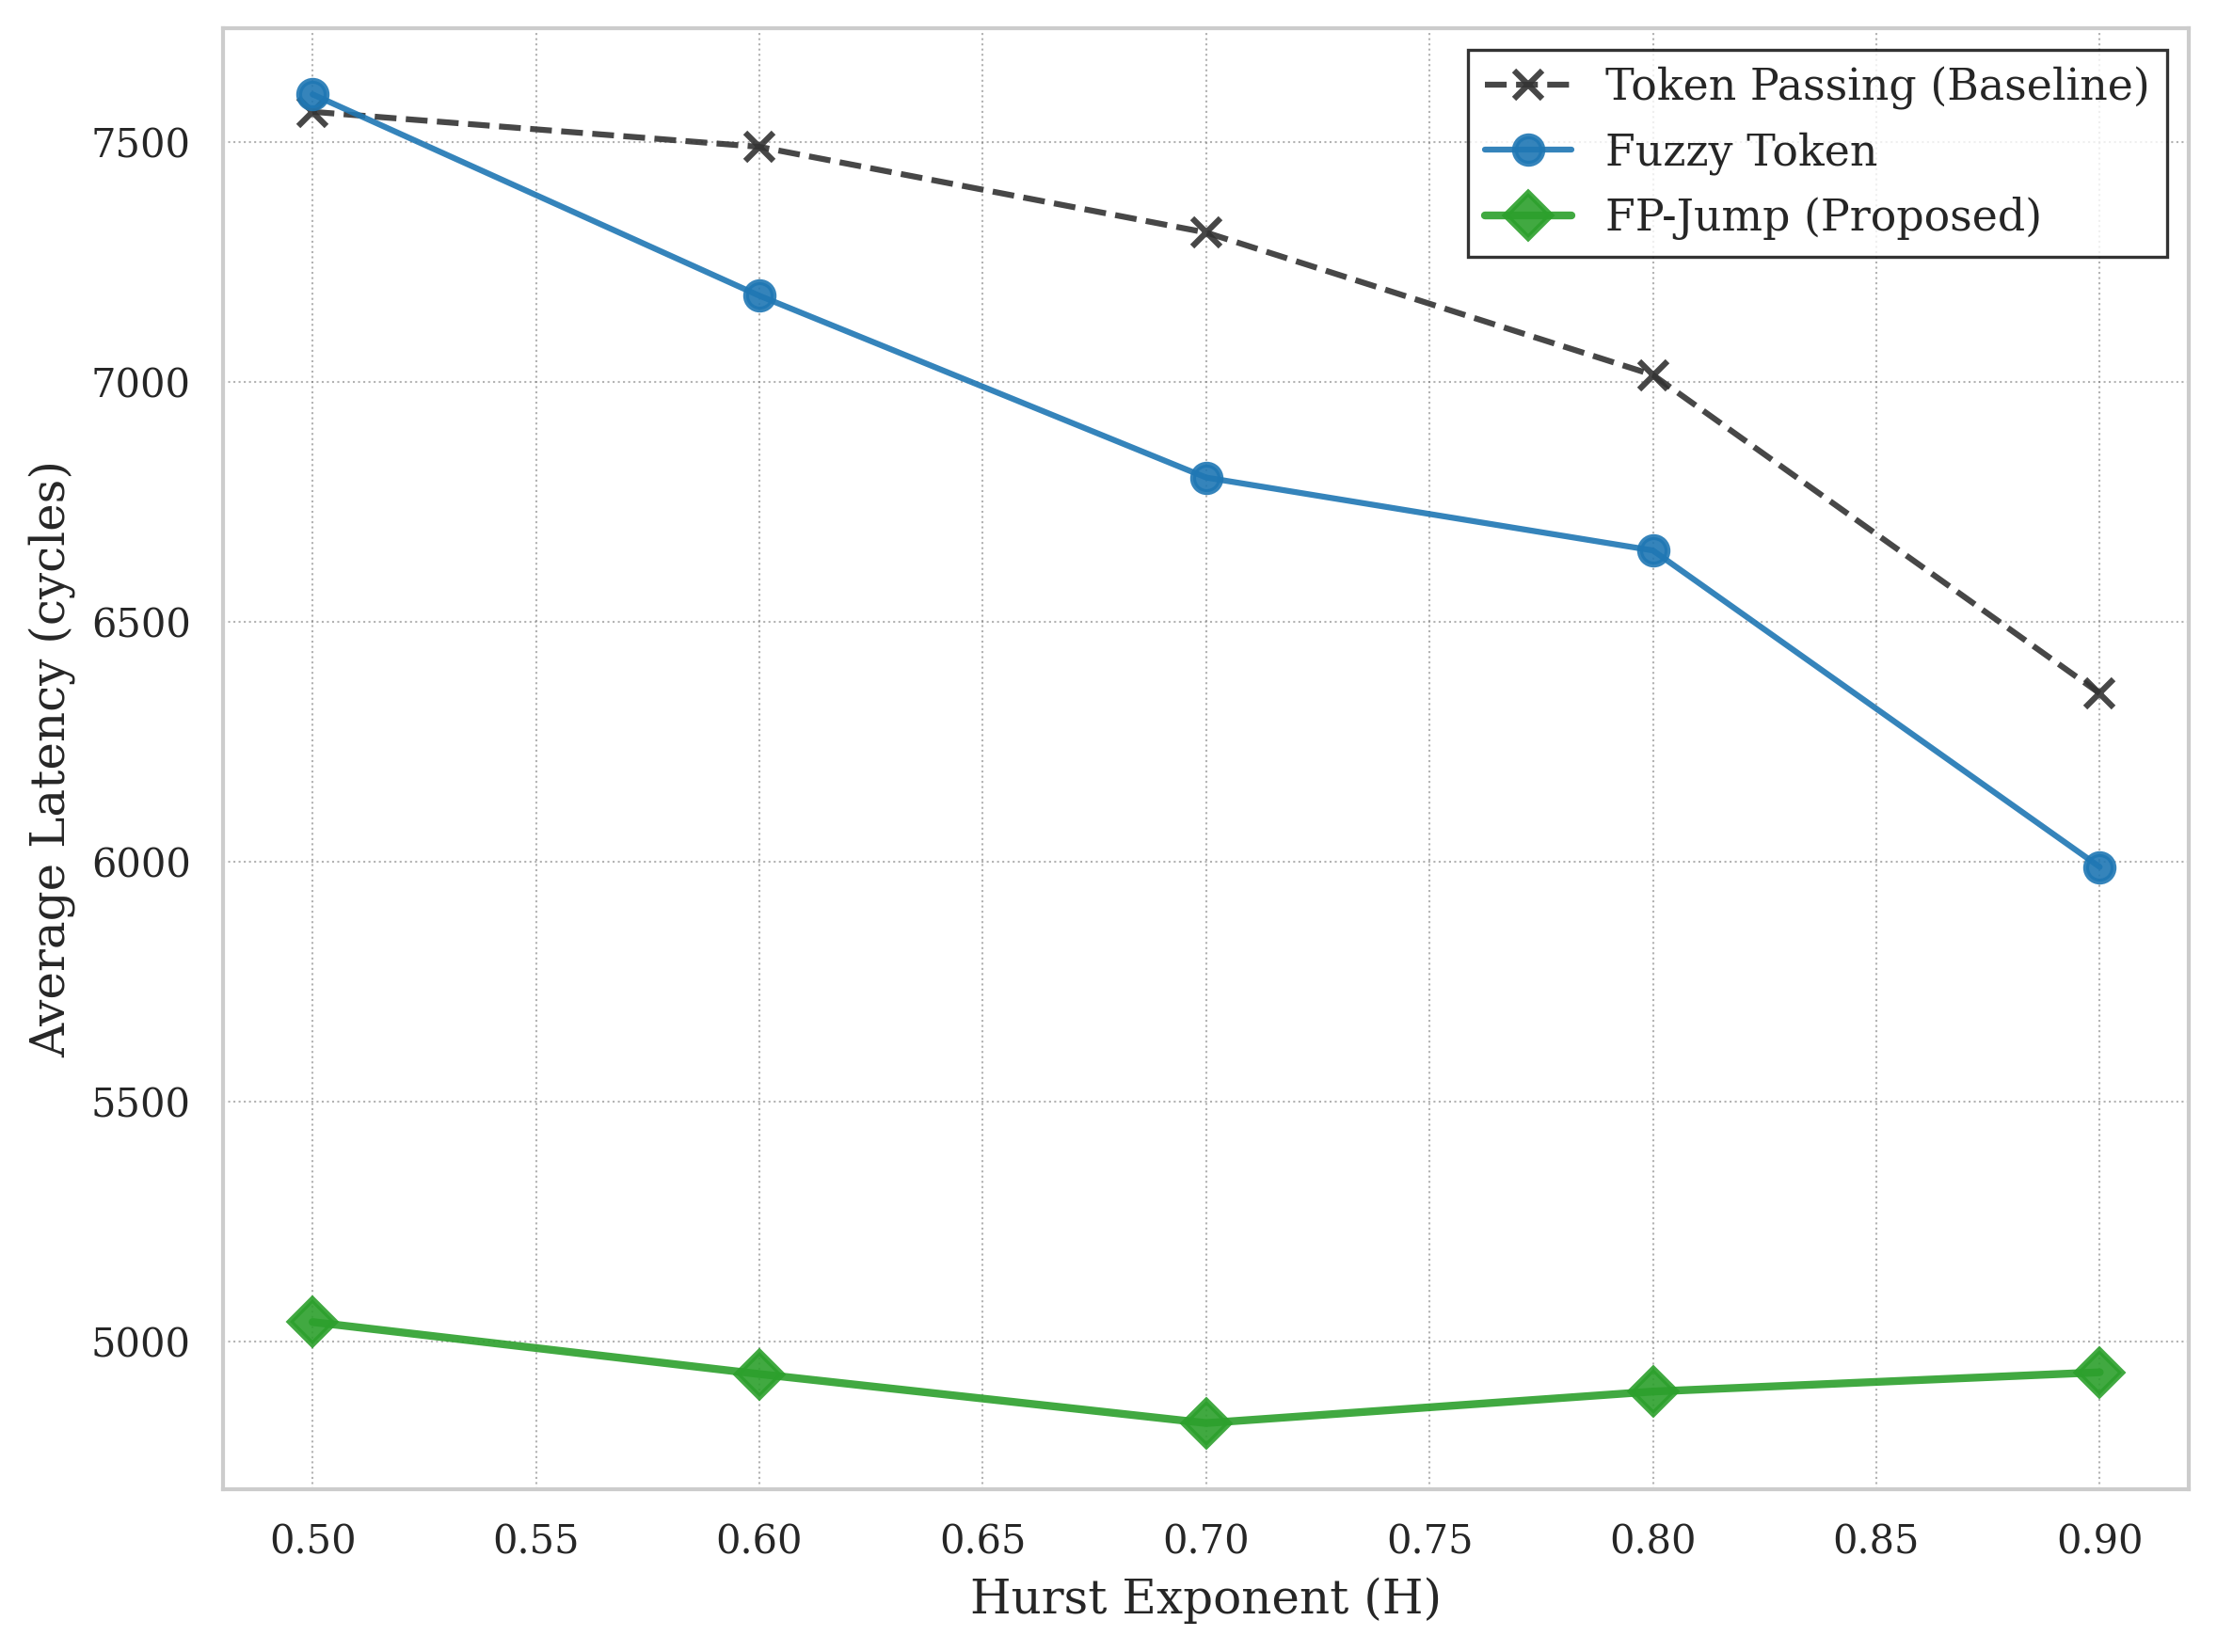

In [57]:
# --- 6. Plotting: Hurst Sweep ---
if not df_hurst.empty:
    plot_comparisons(df_hurst, "hurst", "avg_delay", "Figure 4: Sensitivity to Hurst (H)", "Average Latency (cycles)", filename="fig4_hurst.png")
else:
    print("No Hurst data.")

In [58]:
# --- 7. Simulation: Sigma Sweep (Multi-Seed) ---
# Sensitivity to Spatial Hotspotness (Sigma)

SIGMA_LIST = [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0]
FIXED_PIR_SIGMA = 0.025
RESULTS_SIGMA = []

print("Running Sigma Sweep with parallel execution...")

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    for protocol_name, src_config in PROTOCOLS.items():
        print(f"  Protocol: {protocol_name}")
        with open(src_config, 'r') as f:
            base_cfg = yaml.safe_load(f)
            
        for sigma in SIGMA_LIST:
            futures = []
            for s in SEEDS:
                cfg = base_cfg.copy()
                cfg['traffic_soteriou_hurst'] = 0.5
                cfg['traffic_soteriou_sigma'] = float(sigma)
                
                unique_name = f"sigma_{protocol_name.replace(' ', '')}_S{sigma}_SD{s}.yaml"
                futures.append(executor.submit(run_with_temp_config, cfg, unique_name, s, FIXED_PIR_SIGMA))
                
            runs = [f.result() for f in futures]
                
            agg = aggregate_runs(runs)
            
            entry = {
                "protocol": protocol_name,
                "sigma": sigma,
                "avg_delay": agg.get("global_average_delay"),
                "throughput": agg.get("network_throughput"), 
                "energy_J": agg.get("total_energy"),
                "energy_per_pkt": agg.get("energy_per_pkt"),
                "p95_delay": agg.get("p95_delay"),
                "p99_delay": agg.get("p99_delay"),
                "pkts": agg.get("received_packets")
            }
            RESULTS_SIGMA.append(entry)

df_sigma = pd.DataFrame(RESULTS_SIGMA)
print("Sigma Sweep Complete.")

Running Sigma Sweep with parallel execution...
  Protocol: Token Passing
  Protocol: Fuzzy Token
  Protocol: FP-Jump
Sigma Sweep Complete.


<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/var/folders/18/8hrwl15d0fx27gywdl96mvjc0000gn/T/ipykernel_57339/6253640.py:30: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("$\sigma$ (Low = Hotspot, High = Uniform)")


Saved: /Users/nishkarsh/Programming/noxim/paper_results/plots/fig5_sigma.png


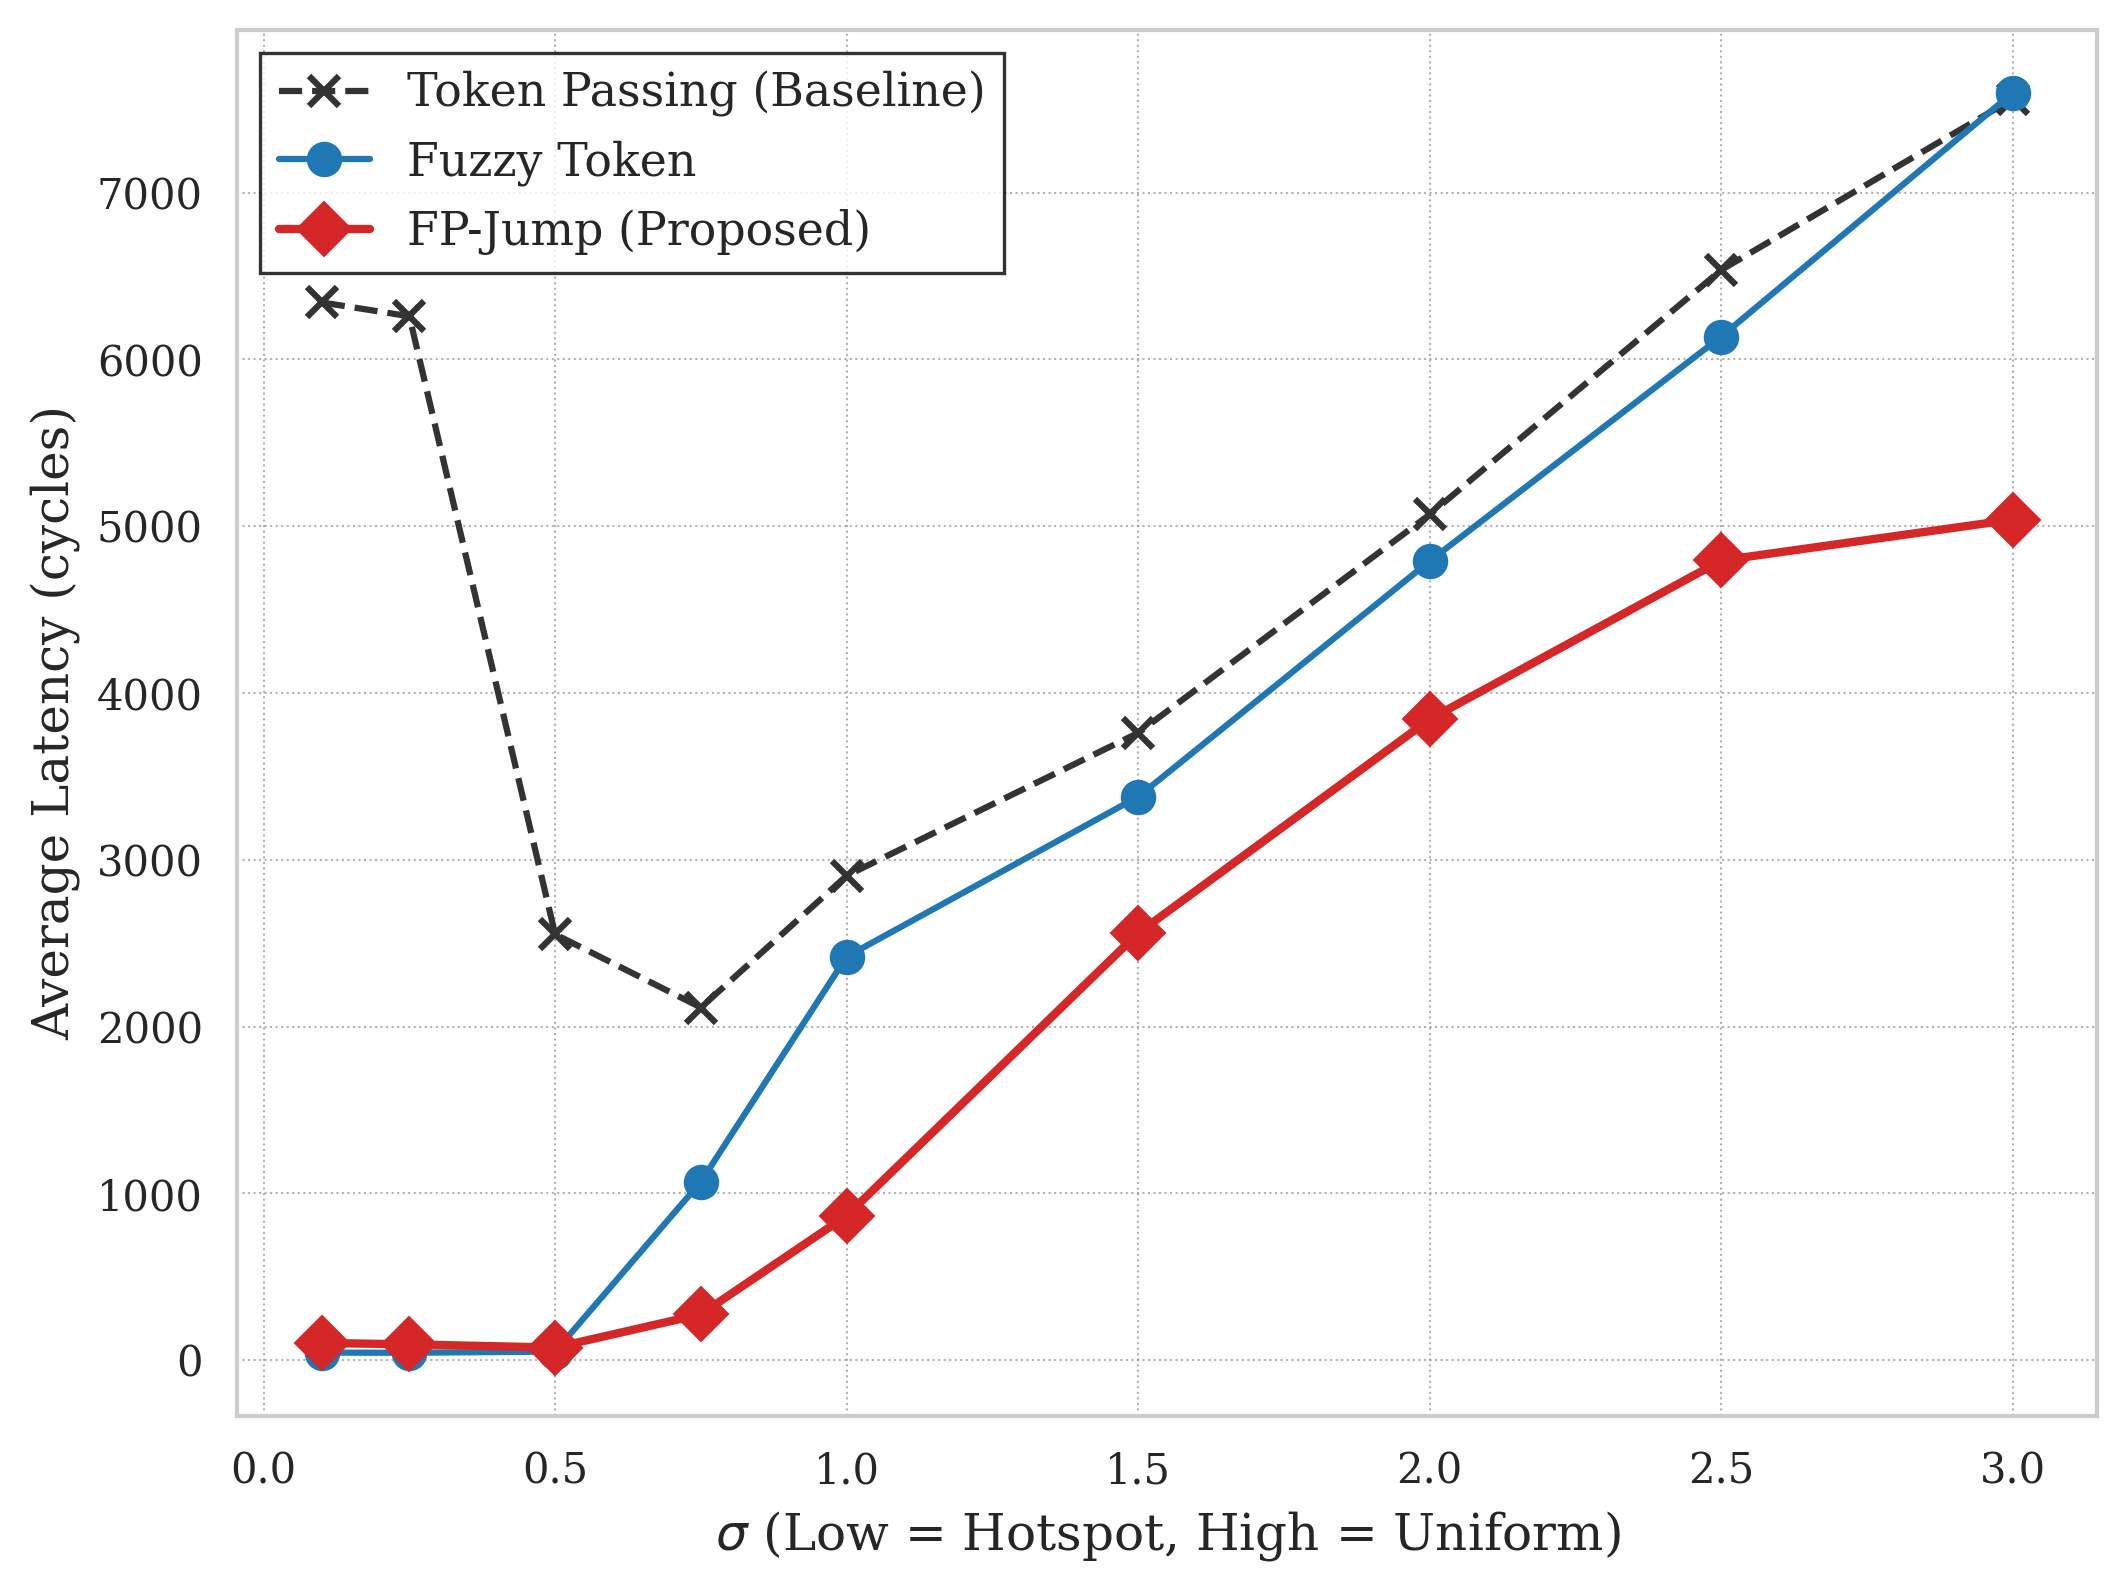

In [59]:
# --- 8. Plotting: Sigma Sweep ---
if not df_sigma.empty:
    # Use generic plotter but custom x-sort since sigma is non-monotonic? No, sigma is float.
    # We might want to invert axis or just label carefully.
    
    plt.figure(figsize=(8, 6))
    
    # Re-use style map logic manually since we want specific Sigma handling
    style_map = {
        "Token Passing":      {"marker": "x", "color": "#333333", "linestyle": "--", "label": "Token Passing (Baseline)"},
        "Fuzzy Token":        {"marker": "o", "color": "#1f77b4", "linestyle": "-",  "label": "Fuzzy Token"},
        "FP-Jump":            {"marker": "D", "color": "#d62728", "linestyle": "-",  "label": "FP-Jump (Proposed)"},
        # "FP-Jump + RG":       {"marker": "^", "color": "#2ca02c", "linestyle": "-.", "label": "FP-Jump + RG (Ideal)"}
    }

    for proto in df_sigma["protocol"].unique():
        if proto not in style_map: continue
        subset = df_sigma[df_sigma["protocol"] == proto].sort_values("sigma")
        s = style_map[proto]
        plt.plot(subset["sigma"], subset["avg_delay"], 
                 label=s["label"], 
                 marker=s["marker"], 
                 color=s["color"],
                 linestyle=s["linestyle"],
                 linewidth=2 if proto == "FP-Jump" else 1.5, 
                 markersize=8 if proto == "FP-Jump" else 7,
                 markeredgewidth=1.5)

    # plt.title("Figure 5: Sensitivity to Spatial Distribution (Sigma)", pad=15)
    plt.xlabel("$\sigma$ (Low = Hotspot, High = Uniform)")
    plt.ylabel("Average Latency (cycles)")
    plt.legend(frameon=True, fancybox=False, edgecolor='black', loc='best')
    plt.grid(True, which="both", linestyle=':', linewidth=0.5, alpha=0.6, color='gray')
    
    save_path = PLOTS_DIR / "fig5_sigma.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()
else:
    print("No Sigma data.")

In [60]:
# --- Section 5: Timeline & Fairness (Viz) ---

# Run one simulation with logging enabled to generate CSV
# Using FP-Jump (fuzzy_swj) as the interesting one
viz_config_src = PROTOCOLS["FP-Jump"]
viz_config_temp = TEMP_CONFIG_DIR / "viz_run.yaml"

with open(viz_config_src, 'r') as f:
    cfg = yaml.safe_load(f)
    
cfg["csv_log_enabled"] = True
cfg["csv_mac_log_filename"] = "viz_log.csv"
cfg["simulation_time"] = 2000 # Short run for viz
cfg["packet_injection_rate"] = 0.02
cfg["traffic_distribution"] = "TRAFFIC_SOTERIOU"

with open(viz_config_temp, 'w') as f:
    yaml.dump(cfg, f)

print("Running Viz Simulation...")
run_noxim(viz_config_temp, seed=SEED)

# Load CSV
csv_path = NOXIM_BIN_DIR / "viz_log.csv"
if csv_path.exists():
    df_log = pd.read_csv(csv_path, dtype={'ready_nodes': str, 'fa_nodes': str})
    
    # 1. Timeline Plot
    sim_limit = 500
    df_slice = df_log[:sim_limit]
    
    plt.figure(figsize=(10, 5)) # Wider, shorter for timeline
    
    # Ready matrix background
    if not df_slice.empty and "ready_nodes" in df_slice.columns:
        num_nodes = 64
        ready_matrix = np.zeros((num_nodes, len(df_slice)))
        for t, ready_str in enumerate(df_slice["ready_nodes"]):
             if isinstance(ready_str, str) and len(ready_str) == num_nodes:
                  for nid, char in enumerate(ready_str):
                      if char == '1': ready_matrix[nid, t] = 1
                      
        cmap = ListedColormap([(1,1,1,0), (0.2, 0.8, 0.2, 0.3)]) # Transparent, Green tint
        plt.imshow(ready_matrix, aspect='auto', origin='lower', 
                   extent=[0, sim_limit, -0.5, 63.5], cmap=cmap, interpolation='nearest')
                   
    plt.plot(df_slice["step_id"], df_slice["current_token_holder"], color='navy', linestyle='-', linewidth=0.8, markersize=2, label="Token Holder")
    plt.title("Timeline: Token Trajectory vs Station Readiness", pad=15)
    plt.xlabel("Simulation Cycle")
    plt.ylabel("Node ID")
    plt.legend(loc='upper right', frameon=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "viz_timeline.png", dpi=300)
    plt.show()

    # 2. Supply vs Demand
    # Count total ready vs total served (token held)
    ready_arr = np.zeros(64)
    served_arr = np.zeros(64)
    
    for idx, row in df_log.iterrows():
        # Ready
        s = row['ready_nodes']
        if isinstance(s, str) and len(s)==64:
             for i, c in enumerate(s):
                 if c=='1': ready_arr[i] += 1
        # Served
        h = int(row['current_token_holder'])
        if 0 <= h < 64:
            served_arr[h] += 1
            
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(ready_arr, served_arr, c=range(64), cmap='viridis', alpha=0.8, s=60, edgecolor='k', linewidth=0.5)
    plt.colorbar(sc, label="Node ID")
    plt.xlabel("Demand (Cycles Ready)")
    plt.ylabel("Supply (Cycles Holding Token)")
    
    # y=x line
    max_val = max(max(ready_arr), max(served_arr))
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label="Ideal Fairness")
    
    plt.title("Supply vs Demand Fairness", pad=15)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "viz_fairness.png", dpi=300)
    plt.show()

else:
    print("CSV Log not found. Simulation might have failed.")

Running Viz Simulation...


NameError: name 'SEED' is not defined